# Sensor Analysis v2 — LC vs PS Cyclic Voltammetry
## UTS AI A — Deteksi Kadmium (Cd²⁺) dengan Feature Engineering Lanjutan

**Pipeline Part 2:**
- **Phase 1:** Load Dataset & Feature Engineering (16 fitur dual-peak)
- **Phase 2:** EDA — Exploratory Data Analysis
- **Phase 3:** Model Training (13 model + Optuna tuning)
- **Phase 4:** Ensemble & Stacking
- **Phase 5:** Evaluasi & Komparasi Final

**Sensor:**
- LC (LecSens): Custom sensor, sweep dimulai ANODIC
- PS (EmStat4 PalmSens): Komersial, sweep dimulai CATHODIC

**Referensi:** CAFF-IBWO paper (Taufiq Choirul Amri et al., Chemical Engineering Journal Advances 2026)

---
## Phase 1 — Load Dataset & Feature Engineering (16 Fitur Dual-Peak)

In [10]:
# Cell 2: Import Library + Konfigurasi
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
from scipy import stats as scipy_stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.4
})

# ==============================================================================
# KONFIGURASI PATH
# ==============================================================================
BASE_DIR   = Path(r'c:\Users\Hikar\Documents\Kuliah\Bahan Belajar Kuliah Semester 4\AI\UTS Kelas AI A')
LC_DIR     = BASE_DIR / 'Alat Sensor LC'
PS_DIR     = BASE_DIR / 'Alat Sensor PS'
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Konsentrasi Cadmium (PPM) — 15 level numerik (KCL/0 ppm ditangani terpisah)
PPM_LEVELS = [2, 4, 6, 8, 10, 20, 40, 60, 80, 100, 200, 400, 600, 800, 1000]

# Scan stabil: indeks 2–9 (scan ke-3 s/d ke-10)
STABLE_SCANS = list(range(2, 10))

# ==============================================================================
# WINDOW PEAK PER SENSOR
# ==============================================================================
# UPPER PEAK (Anodic/Stripping) — Cd²⁺ stripping peak
UPPER_V_MIN_LC, UPPER_V_MAX_LC = -0.62, -0.43   # LC: sempit, hindari spurious peak
UPPER_V_MIN_PS, UPPER_V_MAX_PS = -0.80, -0.43   # PS: lebar, akomodasi peak shift

# LOWER PEAK (Cathodic/Deposition) — Cd²⁺ deposition peak
LOWER_V_MIN_LC, LOWER_V_MAX_LC = -0.80, -0.40   # LC: cathodic return sweep
LOWER_V_MIN_PS, LOWER_V_MAX_PS = -0.90, -0.45   # PS: cathodic forward sweep

# Kolom fitur yang diharapkan (16 fitur dual-peak)
UPPER_FEATURES = ['upper_Ip_mean', 'upper_Ip_std', 'upper_Ep_mean', 'upper_Ep_std',
                  'upper_Area_mean', 'upper_FWHM_mean', 'upper_skewness', 'upper_kurtosis']
LOWER_FEATURES = ['lower_Ip_mean', 'lower_Ip_std', 'lower_Ep_mean', 'lower_Ep_std',
                  'lower_Area_mean', 'lower_FWHM_mean', 'lower_skewness', 'lower_kurtosis']
FEATURE_COLS   = UPPER_FEATURES + LOWER_FEATURES
TARGET_COL     = 'ppm'

print('Konfigurasi berhasil dimuat.')
print(f'  Output         : {OUTPUT_DIR}')
print(f'  Upper peak LC  : [{UPPER_V_MIN_LC}, {UPPER_V_MAX_LC}] V')
print(f'  Upper peak PS  : [{UPPER_V_MIN_PS}, {UPPER_V_MAX_PS}] V')
print(f'  Lower peak LC  : [{LOWER_V_MIN_LC}, {LOWER_V_MAX_LC}] V')
print(f'  Lower peak PS  : [{LOWER_V_MIN_PS}, {LOWER_V_MAX_PS}] V')
print(f'  Total fitur    : {len(FEATURE_COLS)} (8 upper + 8 lower)')

Konfigurasi berhasil dimuat.
  Output         : c:\Users\Hikar\Documents\Kuliah\Bahan Belajar Kuliah Semester 4\AI\UTS Kelas AI A\output
  Upper peak LC  : [-0.62, -0.43] V
  Upper peak PS  : [-0.8, -0.43] V
  Lower peak LC  : [-0.8, -0.4] V
  Lower peak PS  : [-0.9, -0.45] V
  Total fitur    : 16 (8 upper + 8 lower)


---
### Fungsi-Fungsi Preprocessing & Feature Extraction

In [11]:
# Cell 3: load_cv_file() + get_anodic_sweep() + get_cathodic_sweep()

def load_cv_file(filepath, sensor_type='LC'):
    """
    Membaca satu file xlsx hasil ekspor CV.
    Mengembalikan dict {scan_idx: {'V': array, 'I': array}} untuk scan 0-9.
    """
    try:
        if sensor_type == 'LC':
            df = pd.read_excel(filepath, header=[0, 1], sheet_name='Data CV')
        else:
            df = pd.read_excel(filepath, header=[0, 1], sheet_name=0)
    except Exception:
        df = pd.read_excel(filepath, header=[0, 1], sheet_name=0)

    if isinstance(df, dict):
        df = list(df.values())[0]

    scans = {}
    n_scans = df.shape[1] // 2
    for s in range(n_scans):
        v = df.iloc[:, s * 2].dropna().values.astype(float)
        i = df.iloc[:, s * 2 + 1].dropna().values.astype(float)
        if len(v) > 10:
            scans[s] = {'V': v, 'I': i}
    return scans


def _detect_starts_anodic(v):
    """Deteksi apakah scan dimulai dengan sweep anodic (V naik) atau cathodic (V turun)."""
    initial_dv = np.diff(v[:min(10, len(v))])
    return np.mean(initial_dv) > 0  # True = LC (anodic first), False = PS (cathodic first)


def get_anodic_sweep(v, i):
    """
    Mengekstrak bagian ANODIC (stripping) sweep dari satu scan CV.
    - LC (starts_anodic=True) : ambil bagian AWAL hingga turn point V_max
    - PS (starts_anodic=False): ambil bagian AKHIR dari V_min global
    """
    if len(v) < 5:
        return v, i

    starts_anodic = _detect_starts_anodic(v)

    if starts_anodic:
        # LC: anodic sweep = bagian awal scan
        dv = np.diff(v)
        min_anodic_len = max(5, len(v) // 5)
        first_cathodic = [idx for idx in np.where(dv < 0)[0] if idx >= min_anodic_len]
        if not first_cathodic:
            return v, i
        end_idx = first_cathodic[0]
        return v[:end_idx + 1], i[:end_idx + 1]
    else:
        # PS: anodic sweep = bagian akhir scan (setelah V_min)
        turn_idx = int(np.argmin(v))
        return v[turn_idx:], i[turn_idx:]


def get_cathodic_sweep(v, i):
    """
    Mengekstrak bagian CATHODIC (deposition) sweep dari satu scan CV.
    - LC (starts_anodic=True) : sweep cathodic = setelah V_max (return sweep)
    - PS (starts_anodic=False): sweep cathodic = dari awal hingga V_min (forward sweep)
    """
    if len(v) < 5:
        return v, i

    starts_anodic = _detect_starts_anodic(v)

    if starts_anodic:
        # LC: cathodic sweep = setelah V_max (V mulai turun)
        turn_idx = int(np.argmax(v))
        return v[turn_idx:], i[turn_idx:]
    else:
        # PS: cathodic sweep = bagian awal hingga V_min
        turn_idx = int(np.argmin(v))
        return v[:turn_idx + 1], i[:turn_idx + 1]


print('Fungsi load_cv_file, get_anodic_sweep, get_cathodic_sweep berhasil didefinisikan.')

Fungsi load_cv_file, get_anodic_sweep, get_cathodic_sweep berhasil didefinisikan.


In [12]:
# Cell 4: extract_peak_features_v2() — 8 fitur per peak (upper & lower)

def _smooth_signal(iw):
    """Savitzky-Golay smoothing, window=9, polyorder=3."""
    if len(iw) >= 7:
        wl = min(9, len(iw))
        if wl % 2 == 0:
            wl -= 1
        if wl >= 5:
            return savgol_filter(iw, window_length=wl, polyorder=3)
    return iw


def _calc_fwhm(vw, iw):
    """
    Menghitung Full Width at Half Maximum (FWHM) dari peak.
    iw harus sudah positif (baseline-corrected).
    """
    peak_idx = np.argmax(iw)
    half_max = iw[peak_idx] / 2.0
    if half_max <= 0:
        return float('nan')
    left_pts  = np.where(iw[:peak_idx] <= half_max)[0]
    right_pts = np.where(iw[peak_idx:] <= half_max)[0]
    if len(left_pts) == 0 or len(right_pts) == 0:
        return float('nan')
    v_left  = vw[left_pts[-1]]
    v_right = vw[peak_idx + right_pts[0]]
    return float(abs(v_right - v_left))


def extract_upper_peak_features(v_anodic, i_anodic, v_min, v_max):
    """
    Ekstrak 8 fitur dari UPPER (anodic/stripping) peak.
    Baseline correction: 5th-percentile (background subtraction).
    Returns dict dengan key: Ip, Ip_raw, Ep, Area, FWHM, skewness, kurtosis
    atau None jika window terlalu kecil.
    """
    mask = (v_anodic >= v_min) & (v_anodic <= v_max)
    if mask.sum() < 5:
        return None

    vw = v_anodic[mask]
    iw = _smooth_signal(i_anodic[mask])

    # Baseline correction: 5th-percentile
    background = float(np.percentile(iw, 5))
    iw_corr    = iw - background  # tidak di-clip agar FWHM bisa lebih akurat

    # Peak detection
    peak_idx = np.argmax(iw_corr)
    Ip  = float(iw_corr[peak_idx])
    Ep  = float(vw[peak_idx])

    # Area (integral trapezoid, clip ke 0)
    sort_idx = np.argsort(vw)
    area = float(trapezoid(np.clip(iw_corr[sort_idx], 0, None), vw[sort_idx]))

    # FWHM
    iw_pos = np.clip(iw_corr, 0, None)
    fwhm   = _calc_fwhm(vw, iw_pos)

    # Statistical shape features (pada distribusi arus dalam window)
    skew = float(scipy_stats.skew(iw_corr))
    kurt = float(scipy_stats.kurtosis(iw_corr))  # excess kurtosis

    return {'Ip': Ip, 'Ep': Ep, 'Area': area, 'FWHM': fwhm,
            'skewness': skew, 'kurtosis': kurt}


def extract_lower_peak_features(v_cathodic, i_cathodic, v_min, v_max):
    """
    Ekstrak 8 fitur dari LOWER (cathodic/deposition) peak.
    Cathodic current bernilai NEGATIF → flip agar positif sebelum analisis.
    Baseline correction: 95th-percentile (paling positif = background untuk cathodic).
    Returns dict dengan key: Ip, Ep, Area, FWHM, skewness, kurtosis
    atau None jika peak tidak terdeteksi.
    """
    mask = (v_cathodic >= v_min) & (v_cathodic <= v_max)
    if mask.sum() < 5:
        return None

    vw = v_cathodic[mask]
    iw = _smooth_signal(i_cathodic[mask])

    # Untuk cathodic: current negatif, cari argmin (paling negatif)
    peak_idx = np.argmin(iw)

    # Baseline: 95th-percentile (nilai paling tidak negatif sebagai background)
    background = float(np.percentile(iw, 95))
    iw_corr    = background - iw  # flip: positif = ada peak

    Ip  = float(iw_corr[peak_idx])  # magnitude peak
    Ep  = float(vw[peak_idx])        # potential peak

    # Cek apakah peak signifikan (minimal 10% dari range arus)
    i_range = float(np.ptp(iw_corr))
    if Ip < 0.05 or i_range < 0.01:  # sangat lemah → NaN
        return None

    # Area
    sort_idx = np.argsort(vw)
    area = float(trapezoid(np.clip(iw_corr[sort_idx], 0, None), vw[sort_idx]))

    # FWHM
    iw_pos = np.clip(iw_corr, 0, None)
    fwhm   = _calc_fwhm(vw, iw_pos)

    # Statistical shape features
    skew = float(scipy_stats.skew(iw_corr))
    kurt = float(scipy_stats.kurtosis(iw_corr))

    return {'Ip': Ip, 'Ep': Ep, 'Area': area, 'FWHM': fwhm,
            'skewness': skew, 'kurtosis': kurt}


print('Fungsi ekstraksi fitur berhasil didefinisikan.')
print('  Upper peak: 8 fitur (Ip, Ep, Area, FWHM, skewness, kurtosis + Ip_std, Ep_std)')
print('  Lower peak: 8 fitur (sama, dengan baseline flip untuk cathodic)')

Fungsi ekstraksi fitur berhasil didefinisikan.
  Upper peak: 8 fitur (Ip, Ep, Area, FWHM, skewness, kurtosis + Ip_std, Ep_std)
  Lower peak: 8 fitur (sama, dengan baseline flip untuk cathodic)


In [13]:
# Cell 5: process_single_file_v2() dan build_dataset_v2()

def process_single_file_v2(filepath, sensor_type='LC', stable_scans=STABLE_SCANS):
    """
    Memproses satu file xlsx → 16 fitur dual-peak (upper + lower).

    Steps:
    1. Baca semua scan dari file
    2. Pilih scan stabil (indeks 2–9)
    3. Untuk setiap scan:
       a. Ekstrak anodic sweep → upper peak features (8 fitur)
       b. Ekstrak cathodic sweep → lower peak features (8 fitur)
    4. Rata-rata antar scan stabil per fitur
    5. Lower peak NaN jika tidak terdeteksi (ppm rendah — akan di-impute)

    Returns: dict dengan 16 fitur + metadata, atau None jika gagal
    """
    scans = load_cv_file(filepath, sensor_type)

    # Config window per sensor
    if sensor_type == 'LC':
        up_vmin, up_vmax = UPPER_V_MIN_LC, UPPER_V_MAX_LC
        lo_vmin, lo_vmax = LOWER_V_MIN_LC, LOWER_V_MAX_LC
    else:
        up_vmin, up_vmax = UPPER_V_MIN_PS, UPPER_V_MAX_PS
        lo_vmin, lo_vmax = LOWER_V_MIN_PS, LOWER_V_MAX_PS

    upper_results = []
    lower_results = []

    for s_idx in stable_scans:
        if s_idx not in scans:
            continue
        v_full = scans[s_idx]['V']
        i_full = scans[s_idx]['I']

        # ── Upper (Anodic) Peak ────────────────────────────────────────────────
        v_an, i_an = get_anodic_sweep(v_full, i_full)
        if len(v_an) >= 10:
            up_feats = extract_upper_peak_features(v_an, i_an, up_vmin, up_vmax)
            if up_feats is not None:
                upper_results.append(up_feats)

        # ── Lower (Cathodic) Peak ──────────────────────────────────────────────
        v_ca, i_ca = get_cathodic_sweep(v_full, i_full)
        if len(v_ca) >= 10:
            lo_feats = extract_lower_peak_features(v_ca, i_ca, lo_vmin, lo_vmax)
            if lo_feats is not None:
                lower_results.append(lo_feats)

    if not upper_results:
        return None  # Tidak ada scan valid

    # ── Aggregasi: rata-rata + std antar scan ──────────────────────────────────
    def agg_mean(lst, key):
        vals = [r[key] for r in lst if not np.isnan(r[key])]
        return float(np.mean(vals)) if vals else float('nan')

    def agg_std(lst, key):
        vals = [r[key] for r in lst if not np.isnan(r[key])]
        return float(np.std(vals)) if len(vals) > 1 else 0.0

    result = {}

    # Upper peak features
    result['upper_Ip_mean']   = agg_mean(upper_results, 'Ip')
    result['upper_Ip_std']    = agg_std( upper_results, 'Ip')
    result['upper_Ep_mean']   = agg_mean(upper_results, 'Ep')
    result['upper_Ep_std']    = agg_std( upper_results, 'Ep')
    result['upper_Area_mean'] = agg_mean(upper_results, 'Area')
    result['upper_FWHM_mean'] = agg_mean(upper_results, 'FWHM')
    result['upper_skewness']  = agg_mean(upper_results, 'skewness')
    result['upper_kurtosis']  = agg_mean(upper_results, 'kurtosis')

    # Lower peak features (NaN jika tidak terdeteksi)
    if lower_results:
        result['lower_Ip_mean']   = agg_mean(lower_results, 'Ip')
        result['lower_Ip_std']    = agg_std( lower_results, 'Ip')
        result['lower_Ep_mean']   = agg_mean(lower_results, 'Ep')
        result['lower_Ep_std']    = agg_std( lower_results, 'Ep')
        result['lower_Area_mean'] = agg_mean(lower_results, 'Area')
        result['lower_FWHM_mean'] = agg_mean(lower_results, 'FWHM')
        result['lower_skewness']  = agg_mean(lower_results, 'skewness')
        result['lower_kurtosis']  = agg_mean(lower_results, 'kurtosis')
    else:
        for key in ['lower_Ip_mean', 'lower_Ip_std', 'lower_Ep_mean', 'lower_Ep_std',
                    'lower_Area_mean', 'lower_FWHM_mean', 'lower_skewness', 'lower_kurtosis']:
            result[key] = float('nan')

    result['n_upper_valid'] = len(upper_results)
    result['n_lower_valid'] = len(lower_results)
    return result


def build_dataset_v2(sensor_dir, sensor_type, ppm_levels=PPM_LEVELS, include_kcl=True, verbose=True):
    """
    Memuat semua file dari semua folder PPM dan KCL.
    Tiap baris = satu file pengukuran (1 replicate), 16 fitur dual-peak.

    KCL (ppm=0): background elektrolit tanpa Cd²⁺
    Target: log10(ppm + 1) untuk menstabilkan skala (y=0 untuk ppm=0)
    """
    records    = []
    sensor_dir = Path(sensor_dir)

    # ── Load KCL (ppm=0) ───────────────────────────────────────────────────────
    if include_kcl:
        kcl_folder = sensor_dir / 'KCL'
        if kcl_folder.exists():
            kcl_files = sorted(kcl_folder.glob('*.xlsx'))
            n_ok = 0
            for fpath in kcl_files:
                feats = process_single_file_v2(fpath, sensor_type=sensor_type)
                if feats is not None:
                    feats['ppm']      = 0
                    feats['log1p_ppm'] = 0.0            # log10(0+1) = 0
                    feats['filename'] = fpath.name
                    records.append(feats)
                    n_ok += 1
            if verbose:
                print(f'  PPM     0 (KCL): {n_ok}/{len(kcl_files)} file berhasil diproses')
        else:
            if verbose:
                print(f'  [INFO] Folder KCL tidak ditemukan: {kcl_folder}')

    # ── Load level konsentrasi Cd²⁺ ────────────────────────────────────────────
    for ppm in ppm_levels:
        folder = sensor_dir / str(ppm)
        if not folder.exists():
            if verbose:
                print(f'  [WARNING] Folder tidak ditemukan: {folder}')
            continue

        xlsx_files = sorted(folder.glob('*.xlsx'))
        if not xlsx_files:
            if verbose:
                print(f'  [WARNING] Tidak ada file xlsx di: {folder}')
            continue

        n_ok = 0
        for fpath in xlsx_files:
            feats = process_single_file_v2(fpath, sensor_type=sensor_type)
            if feats is not None:
                feats['ppm']       = ppm
                feats['log1p_ppm'] = float(np.log10(ppm + 1))
                feats['filename']  = fpath.name
                records.append(feats)
                n_ok += 1

        if verbose:
            print(f'  PPM {ppm:>5}: {n_ok}/{len(xlsx_files)} file berhasil diproses')

    df = pd.DataFrame(records)
    df = df.sort_values('ppm').reset_index(drop=True)
    return df


print('Fungsi process_single_file_v2 dan build_dataset_v2 berhasil didefinisikan.')

Fungsi process_single_file_v2 dan build_dataset_v2 berhasil didefinisikan.


---
### Load Dataset LC dan PS

In [14]:
# Cell 6: Load Dataset LC dan PS
print('=' * 60)
print('=== Loading Dataset LC (LecSens) ===')
print('=' * 60)
df_lc = build_dataset_v2(LC_DIR, sensor_type='LC')
print(f'\nDataset LC: {df_lc.shape[0]} sampel, {df_lc.shape[1]} kolom')

print()
print('=' * 60)
print('=== Loading Dataset PS (EmStat4) ===')
print('=' * 60)
df_ps = build_dataset_v2(PS_DIR, sensor_type='PS')
print(f'\nDataset PS: {df_ps.shape[0]} sampel, {df_ps.shape[1]} kolom')

=== Loading Dataset LC (LecSens) ===
  PPM     0 (KCL): 50/50 file berhasil diproses
  PPM     2: 50/50 file berhasil diproses
  PPM     4: 50/50 file berhasil diproses
  PPM     6: 50/50 file berhasil diproses
  PPM     8: 50/50 file berhasil diproses
  PPM    10: 50/50 file berhasil diproses
  PPM    20: 50/50 file berhasil diproses
  PPM    40: 50/50 file berhasil diproses
  PPM    60: 50/50 file berhasil diproses
  PPM    80: 50/50 file berhasil diproses
  PPM   100: 50/50 file berhasil diproses
  PPM   200: 50/50 file berhasil diproses
  PPM   400: 50/50 file berhasil diproses
  PPM   600: 50/50 file berhasil diproses
  PPM   800: 50/50 file berhasil diproses
  PPM  1000: 50/50 file berhasil diproses

Dataset LC: 800 sampel, 21 kolom

=== Loading Dataset PS (EmStat4) ===
  PPM     0 (KCL): 50/50 file berhasil diproses
  PPM     2: 50/50 file berhasil diproses
  PPM     4: 50/50 file berhasil diproses
  PPM     6: 50/50 file berhasil diproses
  PPM     8: 50/50 file berhasil dipros

In [15]:
# Cell 7: Simpan ke CSV, Verifikasi, dan Statistik

# ── Simpan ke CSV ─────────────────────────────────────────────────────────────
df_lc.to_csv(OUTPUT_DIR / 'dataset_LC_v2.csv', index=False)
df_ps.to_csv(OUTPUT_DIR / 'dataset_PS_v2.csv', index=False)
print('Dataset disimpan ke output/dataset_LC_v2.csv dan dataset_PS_v2.csv')

# ── Verifikasi ukuran dataset ─────────────────────────────────────────────────
print('\n' + '='*60)
print('VERIFIKASI DATASET')
print('='*60)
print(f'LC: {df_lc.shape[0]} sampel  (expected: 800)')
print(f'PS: {df_ps.shape[0]} sampel  (expected: ~797)')

# Verifikasi distribusi per ppm level
print('\n--- Distribusi sampel per PPM (LC) ---')
lc_dist = df_lc.groupby('ppm').size().reset_index(name='n_samples')
print(lc_dist.to_string(index=False))

print('\n--- Distribusi sampel per PPM (PS) ---')
ps_dist = df_ps.groupby('ppm').size().reset_index(name='n_samples')
print(ps_dist.to_string(index=False))

# ── Cek NaN pada lower peak ────────────────────────────────────────────────────
print('\n' + '='*60)
print('ANALISIS NaN PADA LOWER PEAK FEATURES')
print('='*60)
for sensor_name, df in [('LC', df_lc), ('PS', df_ps)]:
    print(f'\n[{sensor_name}] NaN count per lower peak feature:')
    nan_counts = df[LOWER_FEATURES].isna().sum()
    nan_pct    = (nan_counts / len(df) * 100).round(1)
    nan_df     = pd.DataFrame({'NaN count': nan_counts, 'NaN %': nan_pct})
    print(nan_df.to_string())

# NaN per ppm level (lower_Ip_mean sebagai proxy)
print('\n--- NaN lower_Ip_mean per PPM level (LC) ---')
lc_nan_ppm = df_lc.groupby('ppm')['lower_Ip_mean'].apply(lambda x: x.isna().sum())
print(lc_nan_ppm[lc_nan_ppm > 0].to_string() if lc_nan_ppm.sum() > 0 else 'Tidak ada NaN')

print('\n--- NaN lower_Ip_mean per PPM level (PS) ---')
ps_nan_ppm = df_ps.groupby('ppm')['lower_Ip_mean'].apply(lambda x: x.isna().sum())
print(ps_nan_ppm[ps_nan_ppm > 0].to_string() if ps_nan_ppm.sum() > 0 else 'Tidak ada NaN')

# ── FWHM validity check ───────────────────────────────────────────────────────
print('\n' + '='*60)
print('VALIDITAS UPPER FWHM')
print('='*60)
for sensor_name, df in [('LC', df_lc), ('PS', df_ps)]:
    valid_fwhm = df['upper_FWHM_mean'].notna().sum()
    pct = valid_fwhm / len(df) * 100
    print(f'[{sensor_name}] upper_FWHM_mean valid: {valid_fwhm}/{len(df)} ({pct:.1f}%)')
    status = '✓ OK' if pct >= 80 else '⚠ WARNING: < 80%'
    print(f'  → {status}')

# ── Preview data ──────────────────────────────────────────────────────────────
print('\n--- 5 baris pertama Dataset LC ---')
display_cols = ['ppm', 'log1p_ppm'] + FEATURE_COLS[:6] + ['n_upper_valid', 'n_lower_valid']
display(df_lc[display_cols].head())

# ── Statistik deskriptif ──────────────────────────────────────────────────────
print('\n--- Statistik Deskriptif Upper Features (LC) ---')
display(df_lc[['ppm'] + UPPER_FEATURES].describe().round(4))

print('\n--- Statistik Deskriptif Upper Features (PS) ---')
display(df_ps[['ppm'] + UPPER_FEATURES].describe().round(4))

Dataset disimpan ke output/dataset_LC_v2.csv dan dataset_PS_v2.csv

VERIFIKASI DATASET
LC: 800 sampel  (expected: 800)
PS: 797 sampel  (expected: ~797)

--- Distribusi sampel per PPM (LC) ---
 ppm  n_samples
   0         50
   2         50
   4         50
   6         50
   8         50
  10         50
  20         50
  40         50
  60         50
  80         50
 100         50
 200         50
 400         50
 600         50
 800         50
1000         50

--- Distribusi sampel per PPM (PS) ---
 ppm  n_samples
   0         50
   2         50
   4         50
   6         50
   8         50
  10         50
  20         50
  40         50
  60         49
  80         48
 100         50
 200         50
 400         50
 600         50
 800         50
1000         50

ANALISIS NaN PADA LOWER PEAK FEATURES

[LC] NaN count per lower peak feature:
                 NaN count  NaN %
lower_Ip_mean            0    0.0
lower_Ip_std             0    0.0
lower_Ep_mean            0    0.0
lower_Ep_

,ppm,log1p_ppm,upper_Ip_mean,upper_Ip_std,upper_Ep_mean,upper_Ep_std,upper_Area_mean,upper_FWHM_mean,n_upper_valid,n_lower_valid
0,0,0.0,3.508892,0.879284,-0.61750,0.004330,0.183337,NaN,8,8
1,0,0.0,3.369446,0.419036,-0.51875,0.003307,0.202267,0.053333,8,8
2,0,0.0,3.555563,0.307524,-0.51875,0.003307,0.217111,0.055000,8,8
3,0,0.0,3.664651,0.466183,-0.52000,0.000000,0.225405,0.063333,8,8
4,0,0.0,3.569033,0.480655,-0.51875,0.003307,0.234020,0.066667,8,8



--- Statistik Deskriptif Upper Features (LC) ---


,ppm,upper_Ip_mean,upper_Ip_std,upper_Ep_mean,upper_Ep_std,upper_Area_mean,upper_FWHM_mean,upper_skewness,upper_kurtosis
count,800.0000,800.0000,800.0000,800.0000,800.0000,800.0000,364.0000,800.0000,800.0000
mean,208.1250,8.4305,0.7502,-0.5415,0.0140,0.5032,0.0605,0.0436,-0.6788
std,309.3418,19.5386,0.9040,0.0412,0.0160,1.2247,0.0115,0.5254,0.9061
min,0.0000,0.7097,0.0863,-0.6200,0.0000,0.0431,0.0400,-1.4269,-1.5051
25%,7.5000,1.8545,0.3002,-0.5750,0.0043,0.1011,0.0500,-0.1742,-1.3151
50%,50.0000,2.8342,0.4505,-0.5188,0.0070,0.1563,0.0600,0.0588,-1.1669
75%,250.0000,4.4351,0.6997,-0.5112,0.0217,0.2452,0.0676,0.3504,-0.1751
max,1000.0000,88.7696,7.1843,-0.5000,0.0588,5.6351,0.1000,1.7511,2.6151



--- Statistik Deskriptif Upper Features (PS) ---


,ppm,upper_Ip_mean,upper_Ip_std,upper_Ep_mean,upper_Ep_std,upper_Area_mean,upper_FWHM_mean,upper_skewness,upper_kurtosis
count,797.0000,797.0000,797.0000,797.0000,797.0000,797.0000,211.0000,797.0000,797.0000
mean,208.6324,13.5580,0.6769,-0.6128,0.0080,2.3634,0.1594,-1.3850,2.0806
std,309.8127,9.7525,1.7755,0.0802,0.0169,1.3032,0.0251,0.6852,1.9888
min,0.0000,4.1505,0.0167,-0.7702,0.0000,0.5989,0.0801,-2.9787,-1.4574
25%,6.0000,8.1677,0.1290,-0.6864,0.0000,1.5431,0.1414,-1.7880,0.6776
50%,40.0000,11.9934,0.2619,-0.6401,0.0033,2.0634,0.1551,-1.5123,1.7782
75%,400.0000,16.4010,0.5115,-0.5087,0.0043,2.8703,0.1776,-0.9602,2.9932
max,1000.0000,94.9600,27.3813,-0.5087,0.1052,10.3004,0.2302,0.8798,8.8921


In [16]:
# Cell 8: Impute NaN pada Semua Feature Columns
# NaN pada lower peak WAJAR untuk ppm rendah — peak terlalu lemah
# NaN pada FWHM terjadi saat peak di batas window — impute dengan median
# Kolom all-NaN (lower_FWHM_mean) → isi dengan 0 (tidak ada info, tetap ada kolom)

print('Analisis NaN sebelum imputation:')
for sensor_name, df in [('LC', df_lc), ('PS', df_ps)]:
    nan_total = df[FEATURE_COLS].isna().sum()
    nan_pct   = (nan_total / len(df) * 100).round(1)
    nan_df    = pd.DataFrame({'NaN count': nan_total, 'NaN %': nan_pct})
    print(f'\n[{sensor_name}]')
    print(nan_df[nan_df['NaN count'] > 0].to_string() if nan_total.sum() > 0
          else '  Tidak ada NaN')

def impute_features(df, feature_cols=FEATURE_COLS):
    """
    Impute NaN di semua feature columns:
    - Kolom all-NaN → isi dengan 0 (tidak ada informasi puncak)
    - Kolom partial-NaN → isi dengan median global kolom tersebut
    """
    df_imp = df.copy()
    for col in feature_cols:
        n_nan  = df_imp[col].isna().sum()
        n_all  = len(df_imp[col])
        if n_nan == 0:
            continue
        if n_nan == n_all:
            # Semua NaN → tidak ada informasi → isi 0
            df_imp[col] = 0.0
            print(f'  {col}: semua NaN → diisi 0')
        else:
            # Partial NaN → median global
            med = df_imp[col].median()
            df_imp[col] = df_imp[col].fillna(med)
    return df_imp

print('\nProses imputation...')
df_lc_imp = impute_features(df_lc)
df_ps_imp = impute_features(df_ps)

# Verifikasi: tidak ada NaN tersisa
lc_nan_after = df_lc_imp[FEATURE_COLS].isna().sum().sum()
ps_nan_after = df_ps_imp[FEATURE_COLS].isna().sum().sum()
print(f'\nNaN tersisa setelah imputation — LC: {lc_nan_after}, PS: {ps_nan_after}')

if lc_nan_after == 0 and ps_nan_after == 0:
    print('✓ Semua NaN berhasil di-impute.')
else:
    print('⚠ Masih ada NaN!')
    print('LC:', df_lc_imp[FEATURE_COLS].isna().sum()[df_lc_imp[FEATURE_COLS].isna().sum() > 0])
    print('PS:', df_ps_imp[FEATURE_COLS].isna().sum()[df_ps_imp[FEATURE_COLS].isna().sum() > 0])

# Simpan versi imputed
df_lc_imp.to_csv(OUTPUT_DIR / 'dataset_LC_v2_imputed.csv', index=False)
df_ps_imp.to_csv(OUTPUT_DIR / 'dataset_PS_v2_imputed.csv', index=False)
print('\nDataset imputed disimpan ke:')
print('  output/dataset_LC_v2_imputed.csv')
print('  output/dataset_PS_v2_imputed.csv')

# ── Summary akhir Phase 1 ─────────────────────────────────────────────────────
print('\n' + '='*60)
print('SUMMARY PHASE 1')
print('='*60)
print(f'Dataset LC : {df_lc_imp.shape[0]} sampel × {len(FEATURE_COLS)} fitur')
print(f'Dataset PS : {df_ps_imp.shape[0]} sampel × {len(FEATURE_COLS)} fitur')
print(f'Target     : ppm ({df_lc_imp.ppm.nunique()} level: '
      f'{sorted(int(x) for x in df_lc_imp.ppm.unique())})')
print('\nFitur yang diekstrak:')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {f}')

lc_ok = df_lc_imp.shape[0] == 800
ps_ok = 795 <= df_ps_imp.shape[0] <= 800

print(f'\n  LC = 800 sampel        : {lc_ok}')
print(f'  PS ≈ 797 sampel        : {ps_ok} ({df_ps_imp.shape[0]} sampel)')
print(f'  16 fitur diekstrak     : {len(FEATURE_COLS) == 16}')
print(f'  Tidak ada NaN tersisa  : {lc_nan_after == 0 and ps_nan_after == 0}')

if lc_ok and ps_ok and len(FEATURE_COLS) == 16 and lc_nan_after == 0 and ps_nan_after == 0:
    print('\n✅ Phase 1 SELESAI — Siap lanjut ke Phase 2 (EDA)')
else:
    print('\n⚠ Ada kondisi yang tidak terpenuhi, cek output di atas!')


Analisis NaN sebelum imputation:

[LC]
                 NaN count  NaN %
upper_FWHM_mean        436   54.5
lower_FWHM_mean        800  100.0

[PS]
                 NaN count  NaN %
upper_FWHM_mean        586   73.5
lower_FWHM_mean        797  100.0

Proses imputation...
  lower_FWHM_mean: semua NaN → diisi 0
  lower_FWHM_mean: semua NaN → diisi 0

NaN tersisa setelah imputation — LC: 0, PS: 0
✓ Semua NaN berhasil di-impute.

Dataset imputed disimpan ke:
  output/dataset_LC_v2_imputed.csv
  output/dataset_PS_v2_imputed.csv

SUMMARY PHASE 1
Dataset LC : 800 sampel × 16 fitur
Dataset PS : 797 sampel × 16 fitur
Target     : ppm (16 level: [0, 2, 4, 6, 8, 10, 20, 40, 60, 80, 100, 200, 400, 600, 800, 1000])

Fitur yang diekstrak:
   1. upper_Ip_mean
   2. upper_Ip_std
   3. upper_Ep_mean
   4. upper_Ep_std
   5. upper_Area_mean
   6. upper_FWHM_mean
   7. upper_skewness
   8. upper_kurtosis
   9. lower_Ip_mean
  10. lower_Ip_std
  11. lower_Ep_mean
  12. lower_Ep_std
  13. lower_Area_mean
  

---
## Phase 2 — Exploratory Data Analysis (EDA)
Analisis distribusi 16 fitur terhadap konsentrasi Cd²⁺ (ppm).

| Cell | Isi |
|------|-----|
| Cell 10 | Statistik deskriptif per PPM level |
| Cell 11 | Heatmap korelasi Pearson (16 fitur + ppm) |
| Cell 12 | Boxplot upper peak features per PPM |
| Cell 13 | Boxplot lower peak features per PPM |
| Cell 14 | Calibration curve — upper_Ip_mean vs ppm |
| Cell 15 | Feature importance via Mutual Information |
| Cell 16 | Distribution shift LC vs PS |
| Cell 17 | Ringkasan temuan EDA |

In [17]:
# Cell 10: Statistik Deskriptif per PPM Level
print('='*70)
print('STATISTIK DESKRIPTIF UPPER FEATURES per PPM LEVEL')
print('='*70)

for sensor_name, df in [('LC', df_lc_imp), ('PS', df_ps_imp)]:
    print(f'\n[{sensor_name}] — Mean upper peak features per PPM level:')
    stats_tbl = (df.groupby('ppm')[UPPER_FEATURES]
                   .agg(['mean', 'std'])
                   .round(4))
    # Tampilkan hanya mean (lebih ringkas)
    mean_tbl = df.groupby('ppm')[UPPER_FEATURES].mean().round(4)
    display(mean_tbl)

print('\n[LC] Korelasi Pearson fitur vs ppm:')
lc_corr_ppm = df_lc_imp[FEATURE_COLS + ['ppm']].corr()['ppm'].drop('ppm').sort_values(key=abs, ascending=False)
display(lc_corr_ppm.to_frame('Pearson r (vs ppm)').round(4))

print('\n[PS] Korelasi Pearson fitur vs ppm:')
ps_corr_ppm = df_ps_imp[FEATURE_COLS + ['ppm']].corr()['ppm'].drop('ppm').sort_values(key=abs, ascending=False)
display(ps_corr_ppm.to_frame('Pearson r (vs ppm)').round(4))


STATISTIK DESKRIPTIF UPPER FEATURES per PPM LEVEL

[LC] — Mean upper peak features per PPM level:


,upper_Ip_mean,upper_Ip_std,upper_Ep_mean,upper_Ep_std,upper_Area_mean,upper_FWHM_mean,upper_skewness,upper_kurtosis
ppm,,,,,,,,
0,4.0812,0.4268,-0.5200,0.0044,0.2552,0.0624,-0.0862,-1.1301
2,2.1817,0.2806,-0.5127,0.0106,0.1191,0.0578,0.2305,-1.2310
4,1.9357,0.6580,-0.5938,0.0231,0.1226,0.0597,-0.8449,1.2784
6,1.3957,0.3981,-0.5573,0.0429,0.0691,0.0519,0.3128,-0.7030
8,4.9994,1.2117,-0.6064,0.0203,0.1676,0.0600,0.8306,-0.0187
10,1.7179,0.2450,-0.5185,0.0205,0.0817,0.0535,0.4134,-1.2040
20,2.3292,0.2816,-0.5201,0.0079,0.1194,0.0587,0.3194,-1.1998
40,2.2998,0.3148,-0.5158,0.0129,0.1255,0.0574,0.2122,-1.2859
60,4.2540,0.7333,-0.6125,0.0023,0.1664,0.0601,0.8163,0.0851



[PS] — Mean upper peak features per PPM level:


,upper_Ip_mean,upper_Ip_std,upper_Ep_mean,upper_Ep_std,upper_Area_mean,upper_FWHM_mean,upper_skewness,upper_kurtosis
ppm,,,,,,,,
0,15.7522,0.3148,-0.6185,0.0108,2.8219,0.1497,-1.0544,0.8430
2,8.1997,0.2170,-0.5087,0.0033,1.3610,0.1551,-1.1733,1.5343
4,13.2360,0.1916,-0.6942,0.0021,2.7266,0.1551,-1.7248,1.9498
6,7.6831,0.4208,-0.6012,0.0082,1.4935,0.1598,-2.0894,4.8661
8,18.9616,0.4645,-0.6936,0.0015,2.7743,0.1475,-0.2635,-0.5762
10,9.8754,0.1352,-0.6397,0.0078,1.9707,0.1658,-2.1566,4.7994
20,12.0241,0.3811,-0.6732,0.0016,1.7711,0.1484,-1.0976,2.2585
40,6.6696,0.4144,-0.6832,0.0029,1.3436,0.1551,-2.2168,4.9427
60,17.2588,0.7425,-0.6859,0.0045,3.4976,0.1533,-1.5785,1.8566



[LC] Korelasi Pearson fitur vs ppm:


,Pearson r (vs ppm)
upper_Area_mean,0.6550
upper_Ip_mean,0.6476
lower_Area_mean,0.5956
lower_Ip_mean,0.5807
lower_Ip_std,0.5243
upper_skewness,-0.3801
upper_FWHM_mean,0.3569
upper_Ip_std,0.3495
lower_kurtosis,-0.2570
upper_Ep_mean,0.1576



[PS] Korelasi Pearson fitur vs ppm:


,Pearson r (vs ppm)
lower_Ip_std,0.4612
lower_Area_mean,0.3492
lower_Ip_mean,0.2914
upper_Area_mean,0.2870
upper_Ip_mean,0.2834
upper_Ep_std,0.2396
upper_Ip_std,0.2396
lower_Ep_mean,-0.2371
lower_kurtosis,-0.1645
lower_skewness,-0.1467


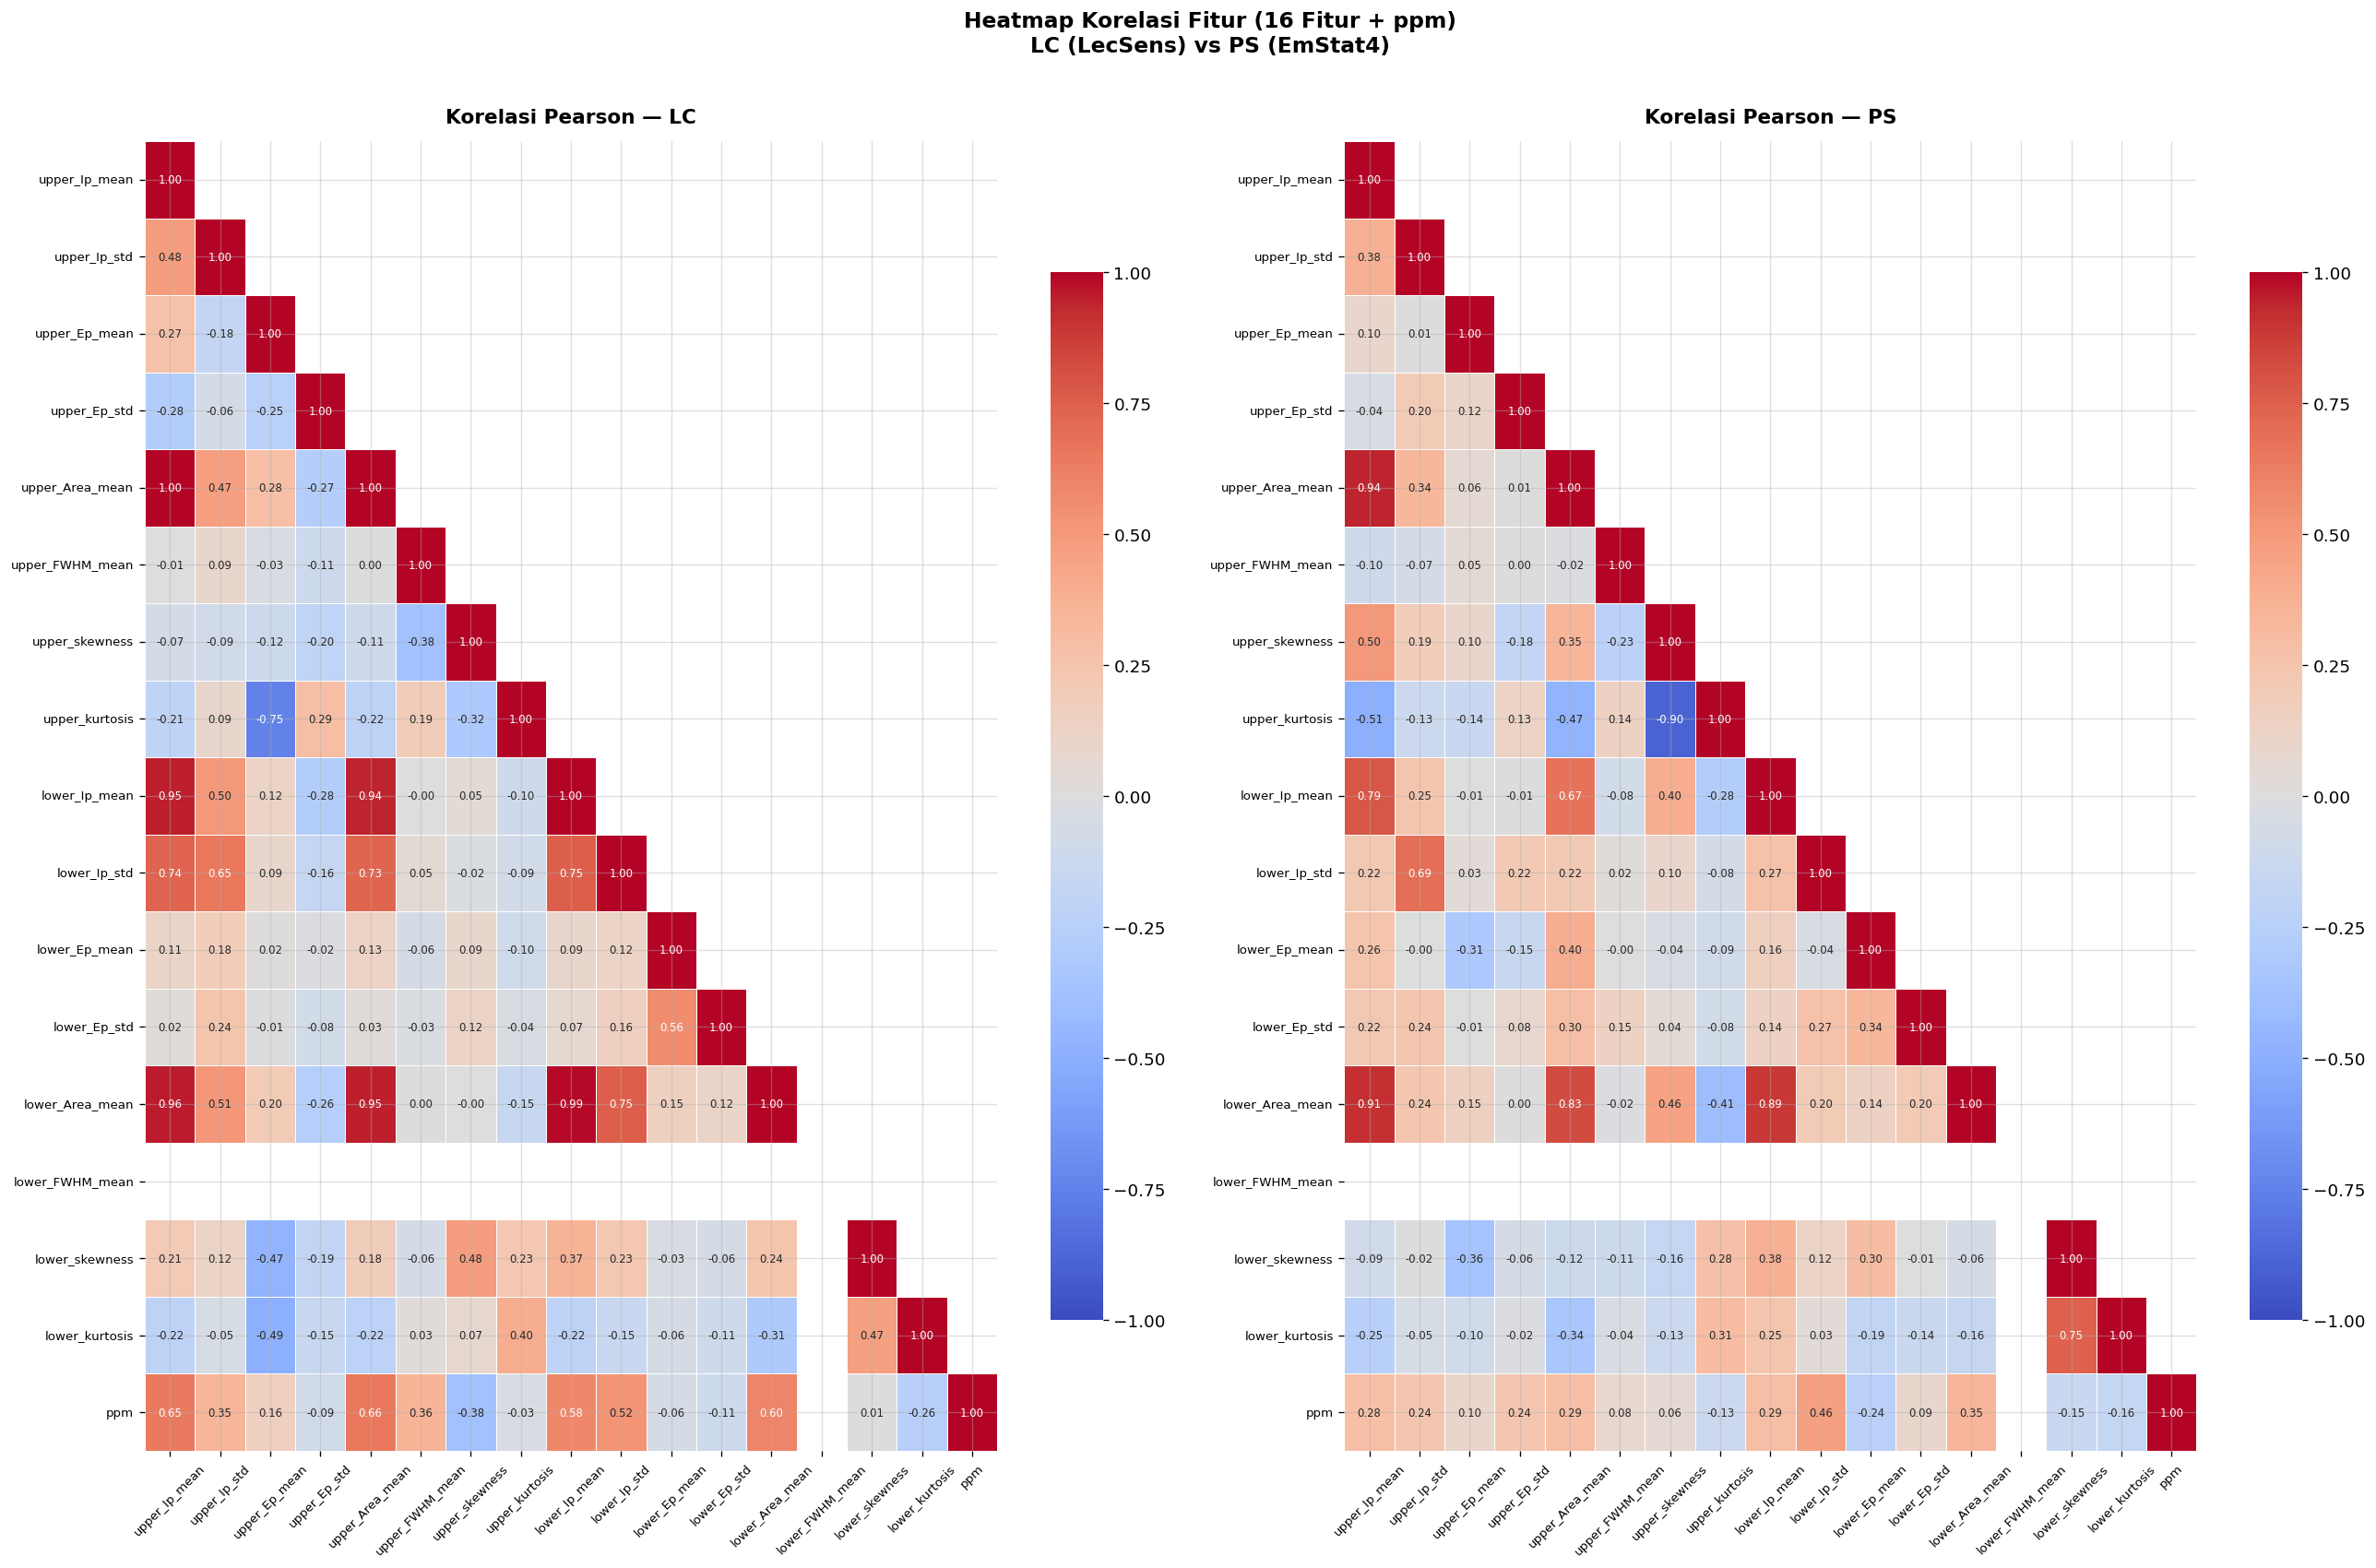

Saved: fig_phase2_correlation.png


In [18]:
# Cell 11: Heatmap Korelasi Pearson (16 fitur + ppm) — LC dan PS
fig, axes = plt.subplots(1, 2, figsize=(22, 14))

for ax, sensor_name, df in zip(axes, ['LC', 'PS'], [df_lc_imp, df_ps_imp]):
    cols_to_corr = FEATURE_COLS + ['ppm']
    corr_matrix  = df[cols_to_corr].corr()

    # Mask segitiga atas agar tidak redundan
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4,
        annot_kws={'size': 7},
        ax=ax,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f'Korelasi Pearson — {sensor_name}', fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

fig.suptitle('Heatmap Korelasi Fitur (16 Fitur + ppm)\nLC (LecSens) vs PS (EmStat4)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phase2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_phase2_correlation.png')


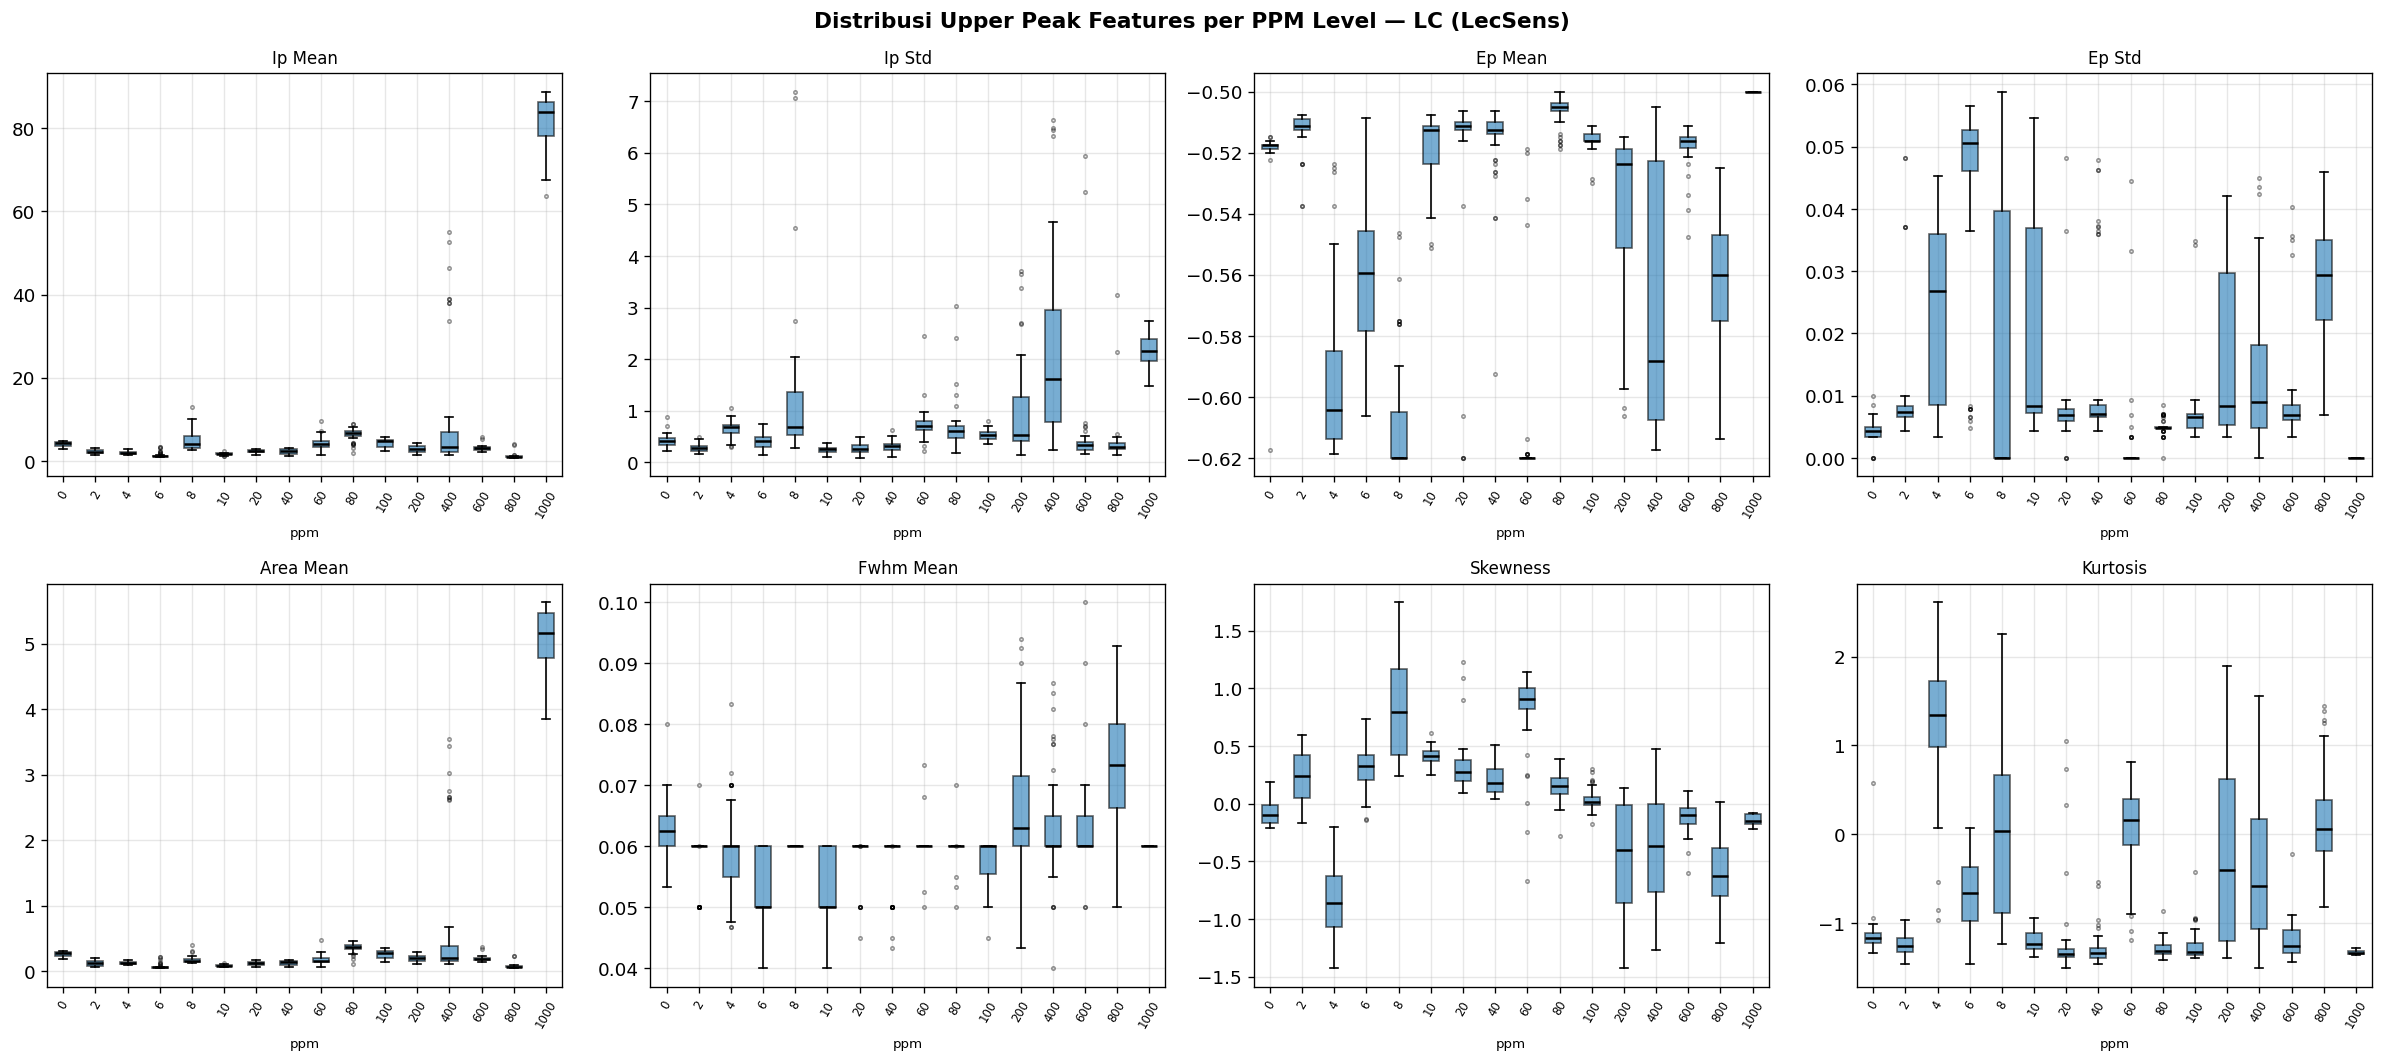

Saved: fig_phase2_boxplot_upper_LC.png


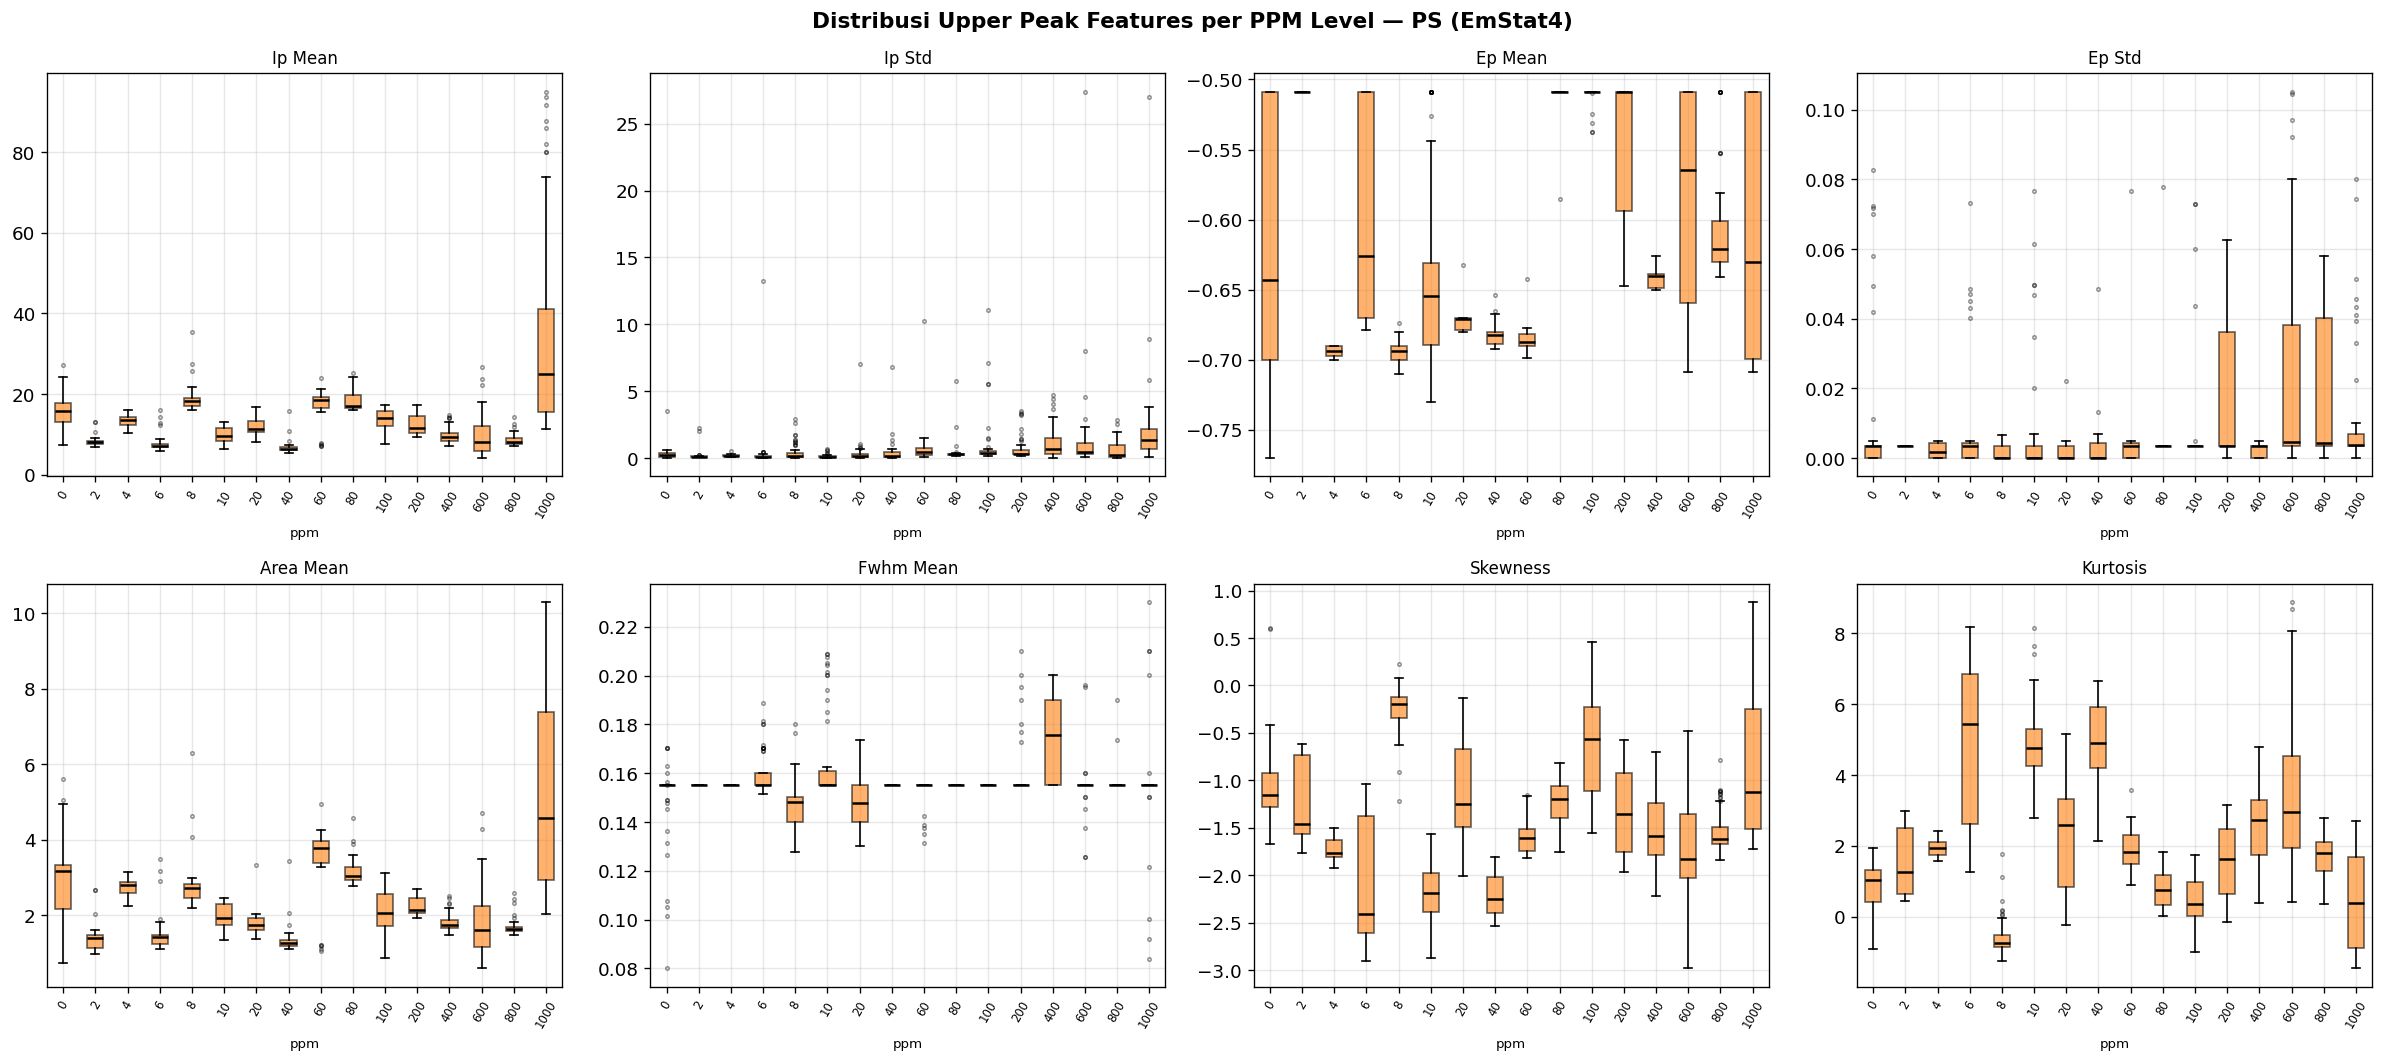

Saved: fig_phase2_boxplot_upper_PS.png


In [19]:
# Cell 12: Boxplot Upper Peak Features per PPM Level — LC dan PS
PPM_LABELS = [str(p) for p in sorted(df_lc_imp['ppm'].unique())]

for sensor_name, df, color, fname in [
    ('LC (LecSens)', df_lc_imp, '#1f77b4', 'fig_phase2_boxplot_upper_LC.png'),
    ('PS (EmStat4)', df_ps_imp, '#ff7f0e', 'fig_phase2_boxplot_upper_PS.png'),
]:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()

    ppm_order = sorted(df['ppm'].unique())

    for ax, feat in zip(axes, UPPER_FEATURES):
        data_by_ppm = [df.loc[df['ppm'] == p, feat].dropna().values for p in ppm_order]
        ax.boxplot(data_by_ppm, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color='black', linewidth=1.5),
                   flierprops=dict(marker='o', markersize=2, alpha=0.4))
        ax.set_xticks(range(1, len(ppm_order) + 1))
        ax.set_xticklabels([str(p) for p in ppm_order], rotation=60, fontsize=7)
        ax.set_title(feat.replace('upper_', '').replace('_', ' ').title(), fontsize=10)
        ax.set_xlabel('ppm', fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'Distribusi Upper Peak Features per PPM Level — {sensor_name}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


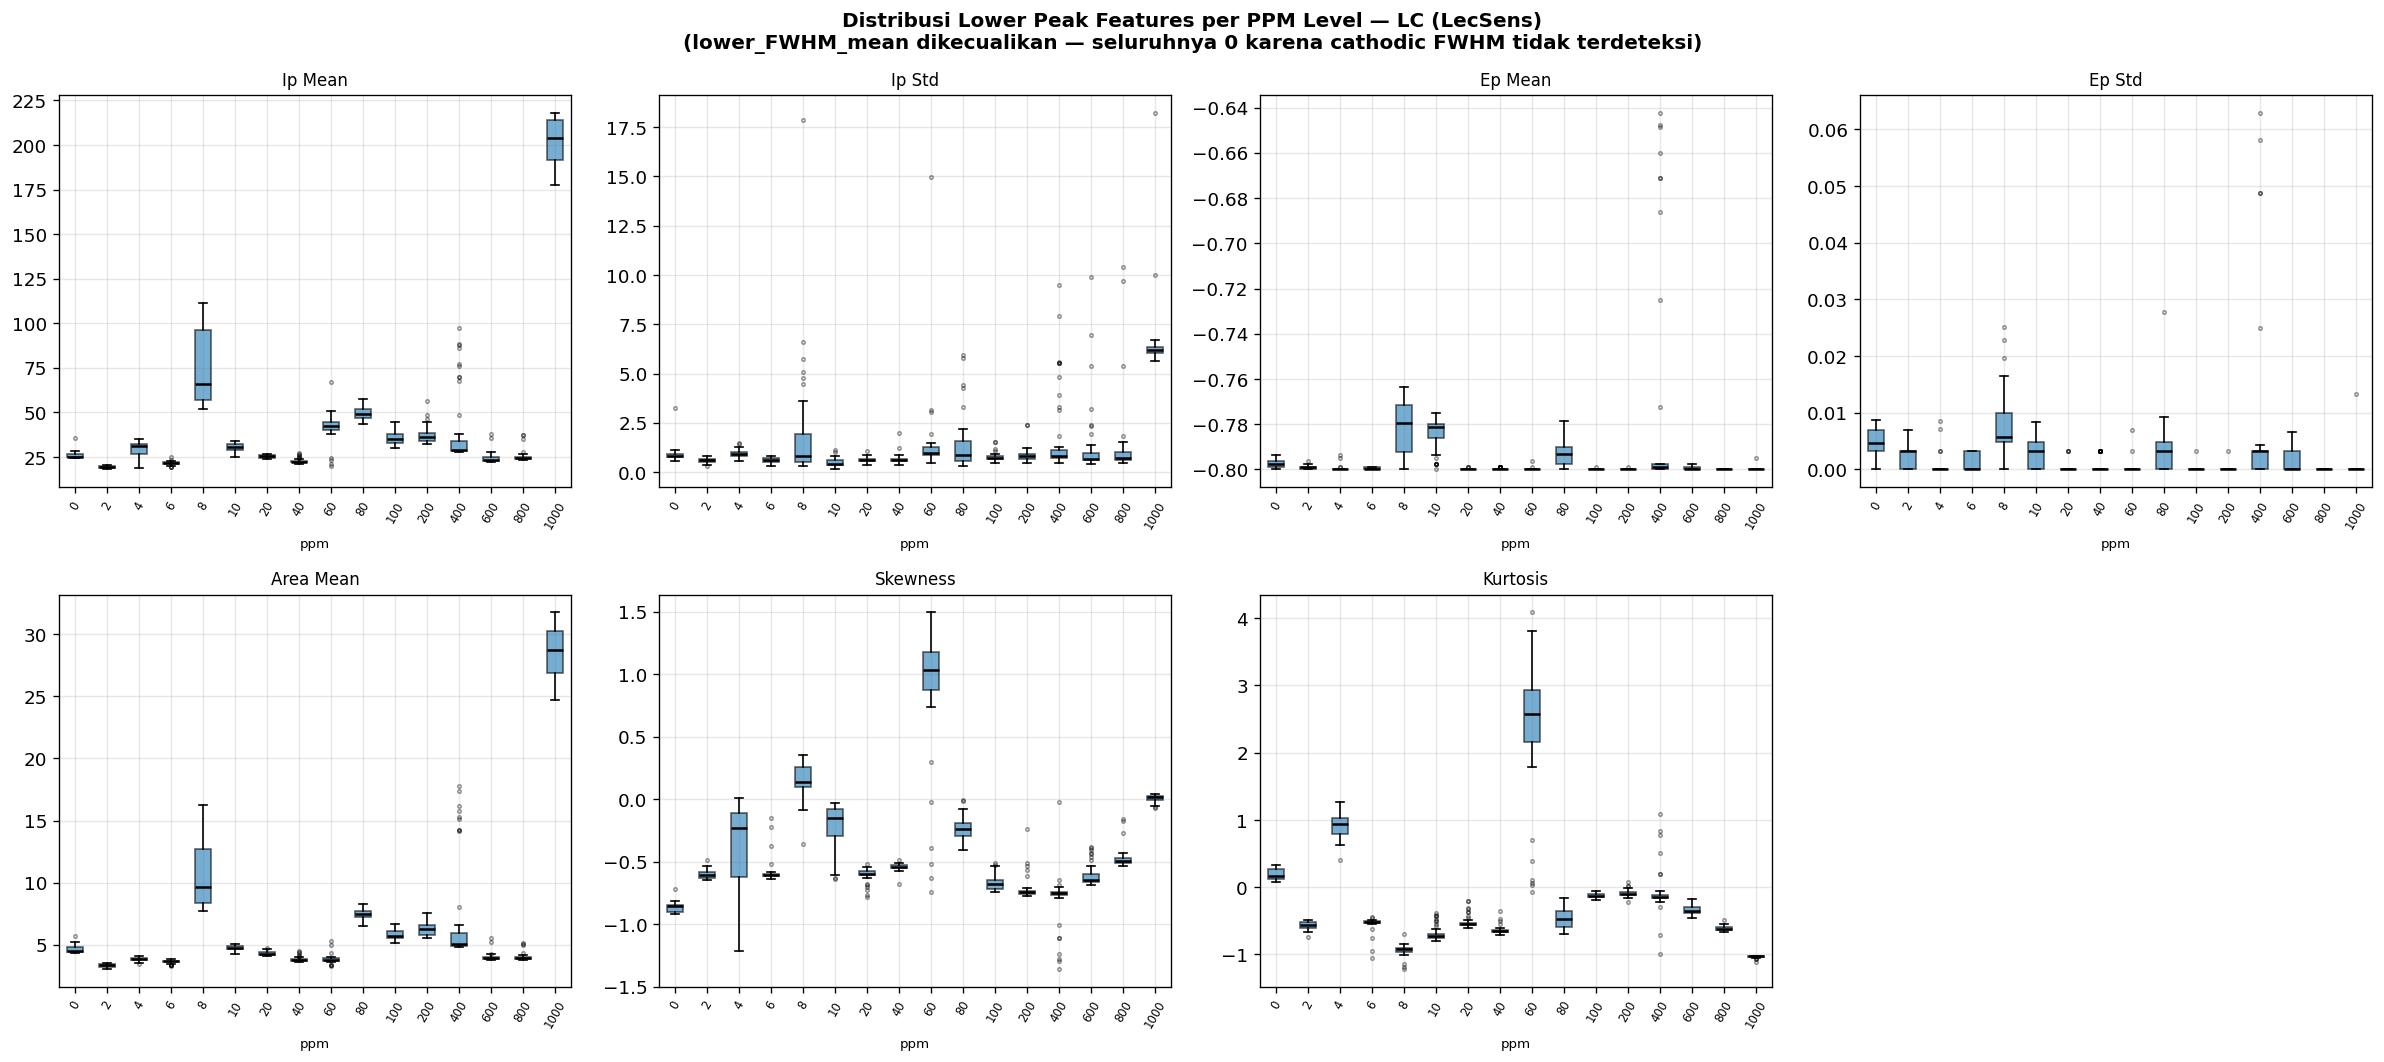

Saved: fig_phase2_boxplot_lower_LC.png


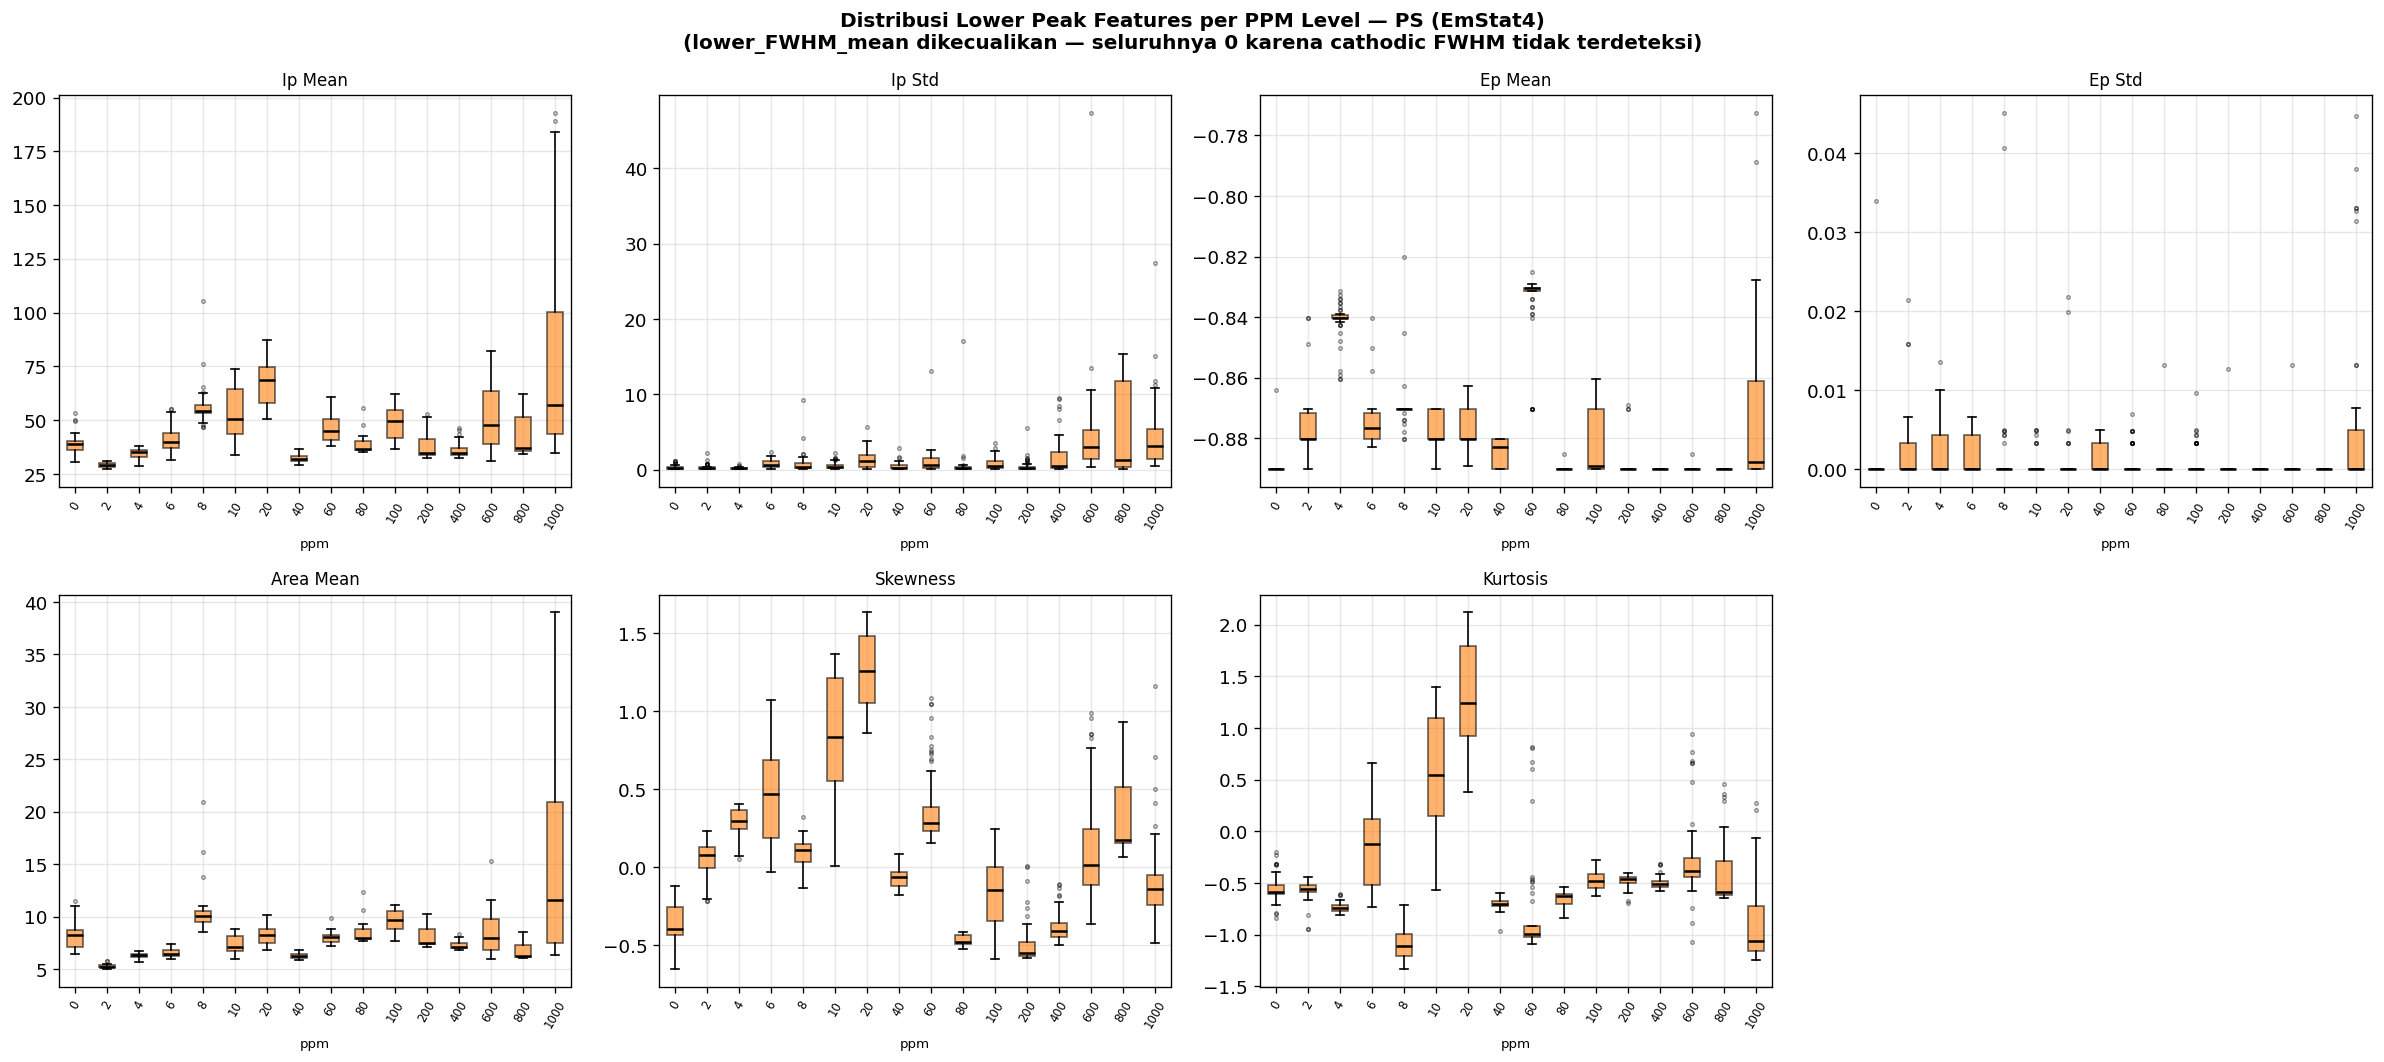

Saved: fig_phase2_boxplot_lower_PS.png


In [20]:
# Cell 13: Boxplot Lower Peak Features per PPM Level — LC dan PS
# Catatan: konsentrasi rendah (0, 2, 4 ppm) sudah di-impute median
# lower_FWHM_mean = 0 untuk semua (tidak ada info) → dikecualikan dari plot informatif

LOWER_FEATURES_PLOT = [f for f in LOWER_FEATURES if f != 'lower_FWHM_mean']

for sensor_name, df, color, fname in [
    ('LC (LecSens)', df_lc_imp, '#1f77b4', 'fig_phase2_boxplot_lower_LC.png'),
    ('PS (EmStat4)', df_ps_imp, '#ff7f0e', 'fig_phase2_boxplot_lower_PS.png'),
]:
    n_feats = len(LOWER_FEATURES_PLOT)
    ncols   = 4
    nrows   = (n_feats + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.5 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

    ppm_order = sorted(df['ppm'].unique())

    for ax, feat in zip(axes, LOWER_FEATURES_PLOT):
        data_by_ppm = [df.loc[df['ppm'] == p, feat].dropna().values for p in ppm_order]
        ax.boxplot(data_by_ppm, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color='black', linewidth=1.5),
                   flierprops=dict(marker='o', markersize=2, alpha=0.4))
        ax.set_xticks(range(1, len(ppm_order) + 1))
        ax.set_xticklabels([str(p) for p in ppm_order], rotation=60, fontsize=7)
        ax.set_title(feat.replace('lower_', '').replace('_', ' ').title(), fontsize=10)
        ax.set_xlabel('ppm', fontsize=8)
        ax.grid(True, alpha=0.3)

    # Sembunyikan axes kosong
    for ax in axes[len(LOWER_FEATURES_PLOT):]:
        ax.set_visible(False)

    fig.suptitle(f'Distribusi Lower Peak Features per PPM Level — {sensor_name}\n'
                 f'(lower_FWHM_mean dikecualikan — seluruhnya 0 karena cathodic FWHM tidak terdeteksi)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


[LC (LecSens)] Linear fit: slope=0.0409, intercept=-0.0825, R²=0.4383
[LC (LecSens)] Log fit   : R²=0.1745
[PS (EmStat4)] Linear fit: slope=0.0089, intercept=11.7231, R²=0.1706
[PS (EmStat4)] Log fit   : R²=0.0569


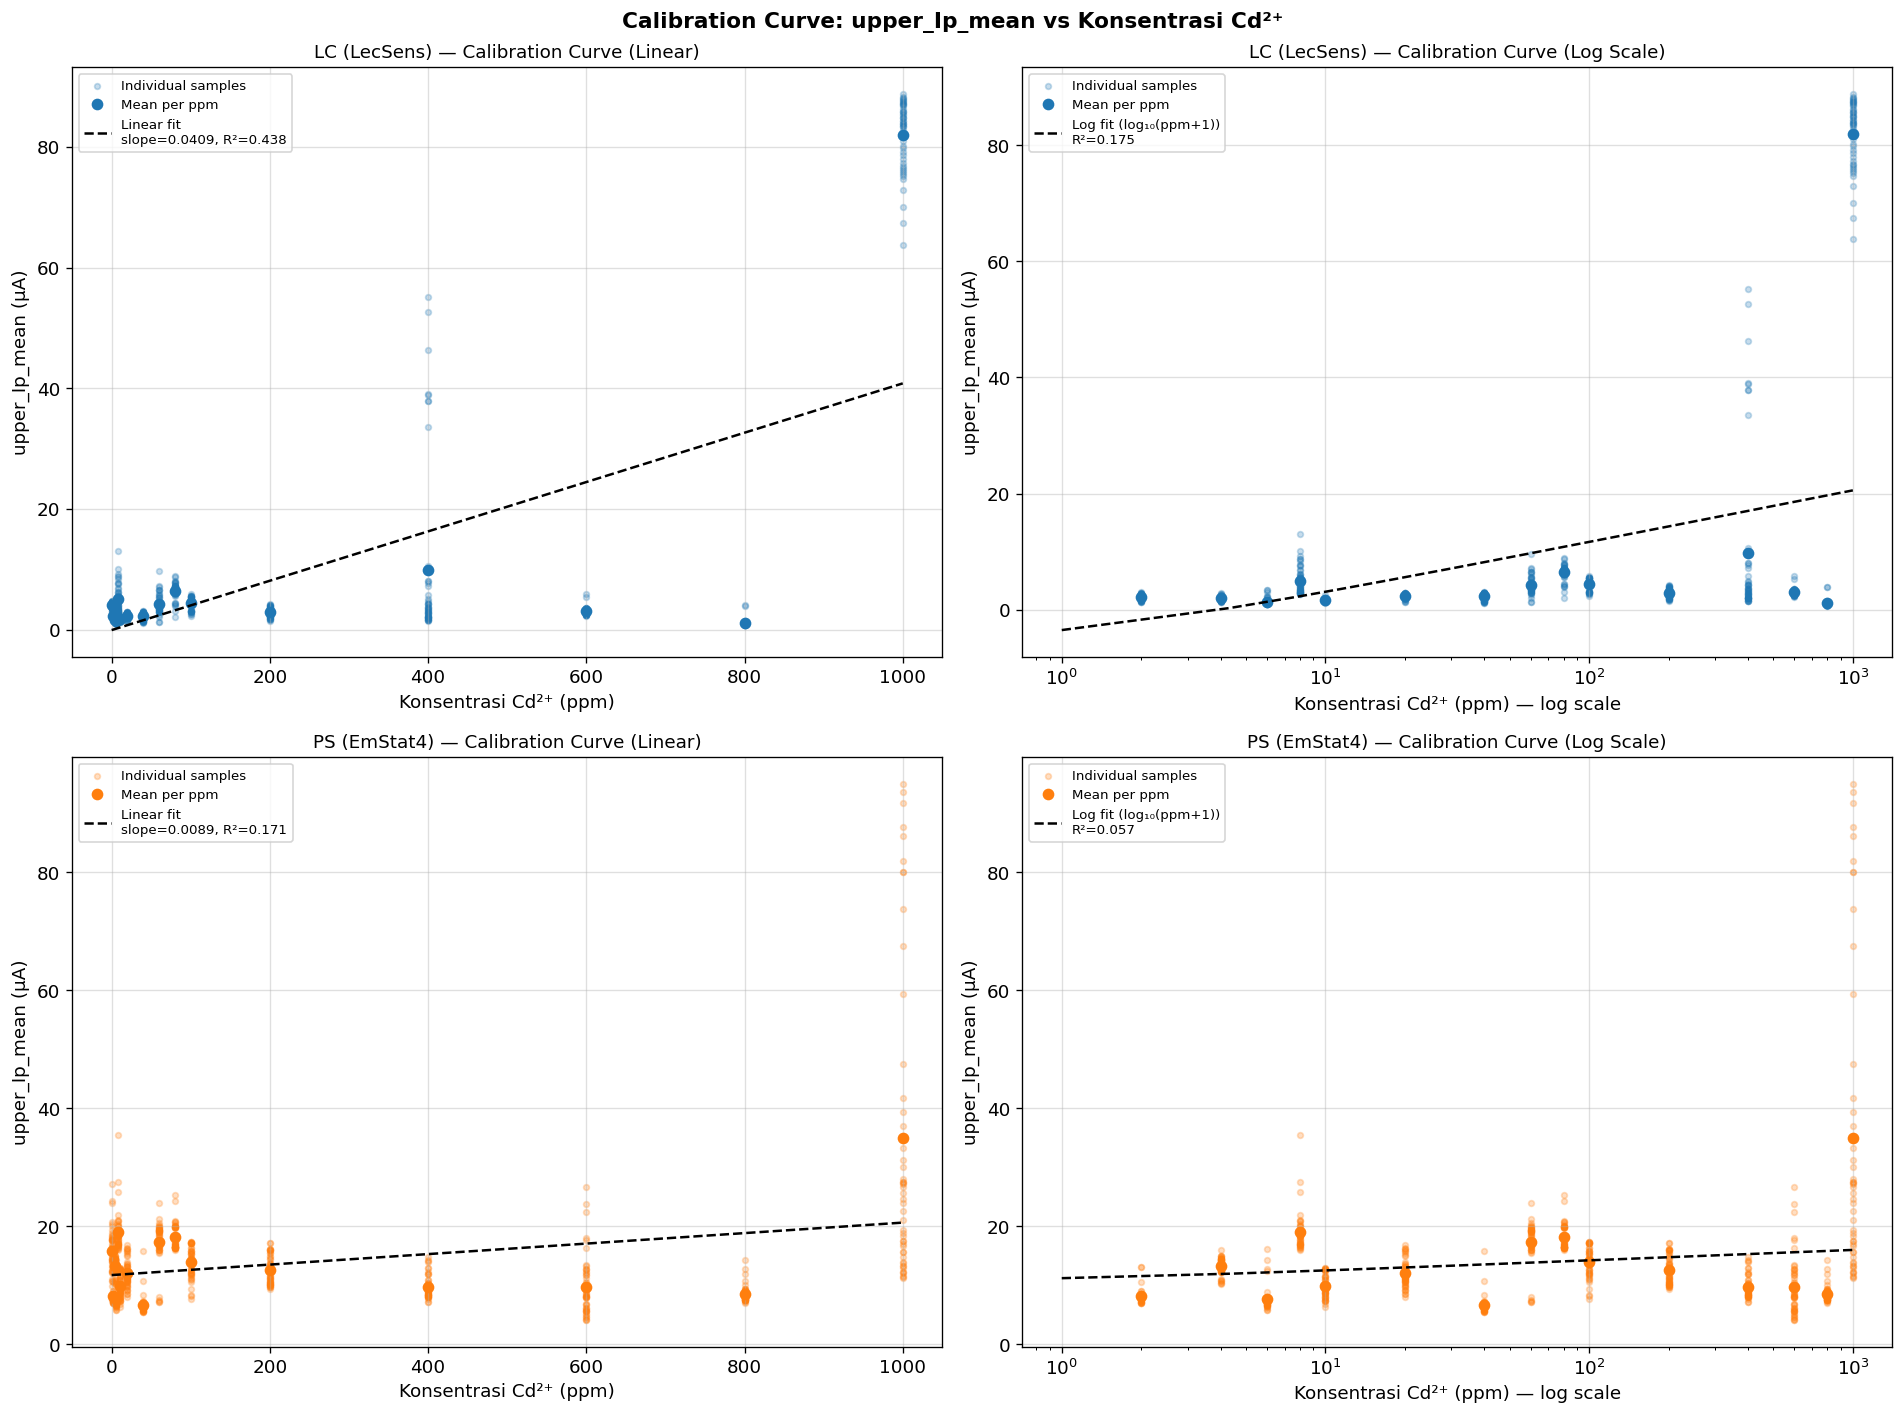

Saved: fig_phase2_calibration.png


In [21]:
# Cell 14: Calibration Curve — upper_Ip_mean vs ppm (Linear + Log scale)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

configs = [
    ('LC (LecSens)', df_lc_imp, '#1f77b4', axes[0]),
    ('PS (EmStat4)', df_ps_imp, '#ff7f0e', axes[1]),
]

for sensor_name, df, color, (ax_lin, ax_log) in configs:
    ppm_vals = df['ppm'].values
    ip_vals  = df['upper_Ip_mean'].values

    # Rata-rata per ppm untuk fit
    ppm_means = df.groupby('ppm')['upper_Ip_mean'].mean()
    ppm_x     = ppm_means.index.values.astype(float)
    ip_y      = ppm_means.values

    # Linear fit (semua ppm)
    coeffs_lin = np.polyfit(ppm_x, ip_y, 1)
    p_lin      = np.poly1d(coeffs_lin)
    ppm_line   = np.linspace(0, 1000, 300)
    r2_lin     = float(np.corrcoef(ip_y, p_lin(ppm_x))[0, 1] ** 2)

    # Log fit: fit pada log10(ppm+1)
    log_x    = np.log10(ppm_x + 1)
    coeffs_log = np.polyfit(log_x, ip_y, 1)
    p_log    = np.poly1d(coeffs_log)
    log_line = np.log10(ppm_line + 1)
    r2_log   = float(np.corrcoef(ip_y, p_log(log_x))[0, 1] ** 2)

    # ── Linear scale plot ─────────────────────────────────────────────────────
    ax_lin.scatter(ppm_vals, ip_vals, c=color, alpha=0.25, s=12, label='Individual samples')
    ax_lin.plot(ppm_x, ip_y, 'o', color=color, markersize=6, label='Mean per ppm')
    ax_lin.plot(ppm_line, p_lin(ppm_line), '--', color='black', linewidth=1.5,
                label=f'Linear fit\nslope={coeffs_lin[0]:.4f}, R²={r2_lin:.3f}')
    ax_lin.set_title(f'{sensor_name} — Calibration Curve (Linear)', fontsize=11)
    ax_lin.set_xlabel('Konsentrasi Cd²⁺ (ppm)')
    ax_lin.set_ylabel('upper_Ip_mean (µA)')
    ax_lin.legend(fontsize=8)

    # ── Log scale plot ────────────────────────────────────────────────────────
    ppm_nonzero   = ppm_vals[ppm_vals > 0]
    ip_nonzero    = ip_vals[ppm_vals > 0]
    ax_log.scatter(ppm_nonzero, ip_nonzero, c=color, alpha=0.25, s=12, label='Individual samples')
    ppm_x_nz = ppm_x[ppm_x > 0]
    ip_y_nz  = ip_y[ppm_x > 0]
    ax_log.plot(ppm_x_nz, ip_y_nz, 'o', color=color, markersize=6, label='Mean per ppm')
    ppm_line_nz = np.linspace(1, 1000, 300)
    ax_log.plot(ppm_line_nz, p_log(np.log10(ppm_line_nz + 1)), '--', color='black',
                linewidth=1.5,
                label=f'Log fit (log₁₀(ppm+1))\nR²={r2_log:.3f}')
    ax_log.set_xscale('log')
    ax_log.set_title(f'{sensor_name} — Calibration Curve (Log Scale)', fontsize=11)
    ax_log.set_xlabel('Konsentrasi Cd²⁺ (ppm) — log scale')
    ax_log.set_ylabel('upper_Ip_mean (µA)')
    ax_log.legend(fontsize=8)

    print(f'[{sensor_name}] Linear fit: slope={coeffs_lin[0]:.4f}, intercept={coeffs_lin[1]:.4f}, R²={r2_lin:.4f}')
    print(f'[{sensor_name}] Log fit   : R²={r2_log:.4f}')

fig.suptitle('Calibration Curve: upper_Ip_mean vs Konsentrasi Cd²⁺', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phase2_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_phase2_calibration.png')



[LC (LecSens)] Top 5 fitur (MI score):
lower_kurtosis     1.642465
lower_Area_mean    1.631963
lower_Ip_mean      1.565326
lower_skewness     1.449267
upper_Ip_mean      1.181552

[PS (EmStat4)] Top 5 fitur (MI score):
upper_Ep_mean      1.101889
lower_skewness     0.961050
lower_kurtosis     0.960438
lower_Ep_mean      0.875343
lower_Area_mean    0.845190


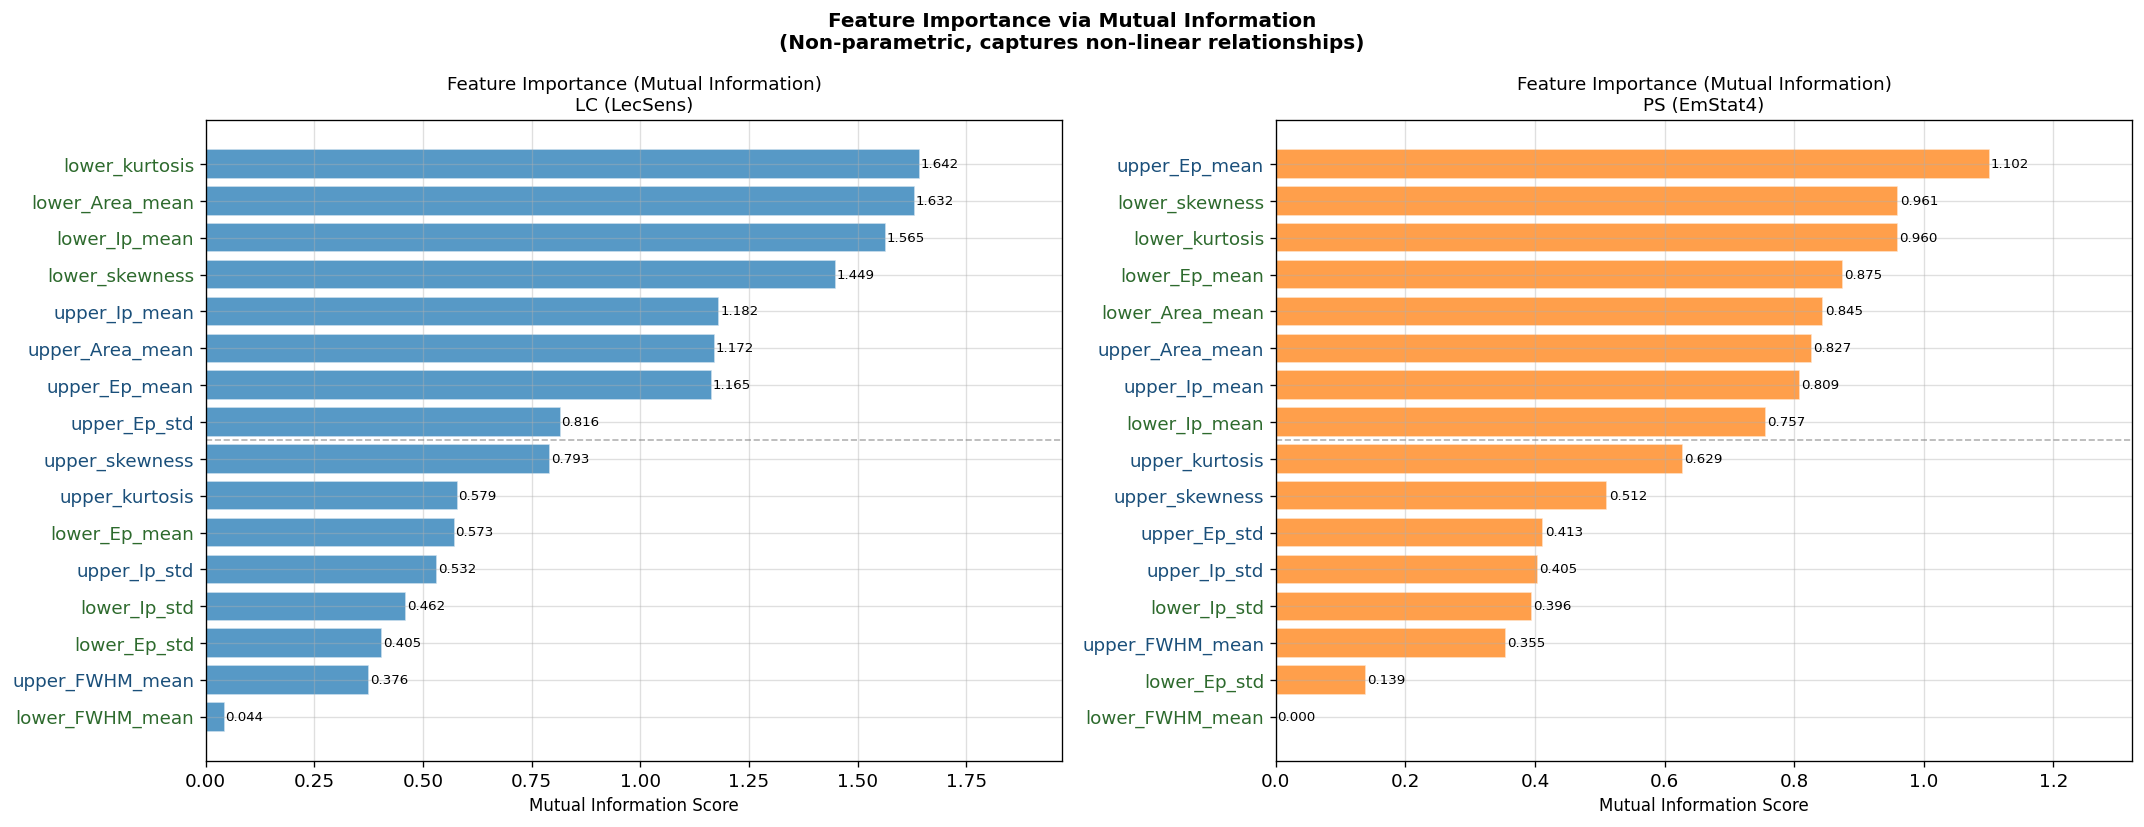


Saved: fig_phase2_mutual_info.png

--- Komparasi MI Score: LC vs PS ---


,LC MI,PS MI
lower_Area_mean,1.6320,0.8452
lower_Ep_mean,0.5728,0.8753
lower_Ep_std,0.4050,0.1391
lower_FWHM_mean,0.0436,0.0000
lower_Ip_mean,1.5653,0.7567
lower_Ip_std,0.4615,0.3956
lower_kurtosis,1.6425,0.9604
lower_skewness,1.4493,0.9610
upper_Area_mean,1.1715,0.8275
upper_Ep_mean,1.1647,1.1019


In [22]:
# Cell 15: Feature Importance via Mutual Information
from sklearn.feature_selection import mutual_info_regression

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mi_results = {}
for ax, sensor_name, df, color in [
    (axes[0], 'LC (LecSens)', df_lc_imp, '#1f77b4'),
    (axes[1], 'PS (EmStat4)', df_ps_imp, '#ff7f0e'),
]:
    X_mi = df[FEATURE_COLS].values
    y_mi = df['ppm'].values

    # Mutual Information (non-parametric, captures non-linear relationships)
    mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
    mi_series = pd.Series(mi_scores, index=FEATURE_COLS).sort_values(ascending=True)
    mi_results[sensor_name] = mi_series

    # Bar chart horizontal
    bars = ax.barh(mi_series.index, mi_series.values, color=color, alpha=0.75, edgecolor='white')

    # Anotasi nilai
    for bar, val in zip(bars, mi_series.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='left', fontsize=8)

    # Garis pemisah upper vs lower features
    n_lower = sum(1 for f in mi_series.index if f.startswith('lower_'))
    n_upper = len(mi_series) - n_lower
    ax.axhline(y=n_lower - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_xlabel('Mutual Information Score', fontsize=10)
    ax.set_title(f'Feature Importance (Mutual Information)\n{sensor_name}', fontsize=11)
    ax.set_xlim(0, mi_series.max() * 1.2)

    # Warna label: biru tua = upper, hijau = lower
    for label in ax.get_yticklabels():
        if label.get_text().startswith('upper_'):
            label.set_color('#1a4f7a')
        else:
            label.set_color('#2d6a2d')

    print(f'\n[{sensor_name}] Top 5 fitur (MI score):')
    print(mi_series.sort_values(ascending=False).head(5).to_string())

fig.suptitle('Feature Importance via Mutual Information\n(Non-parametric, captures non-linear relationships)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phase2_mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: fig_phase2_mutual_info.png')

# Perbandingan LC vs PS
print('\n--- Komparasi MI Score: LC vs PS ---')
mi_comparison = pd.DataFrame({
    'LC MI':   mi_results['LC (LecSens)'].sort_values(ascending=False),
    'PS MI':   mi_results['PS (EmStat4)'].sort_values(ascending=False),
}).round(4)
display(mi_comparison)


LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

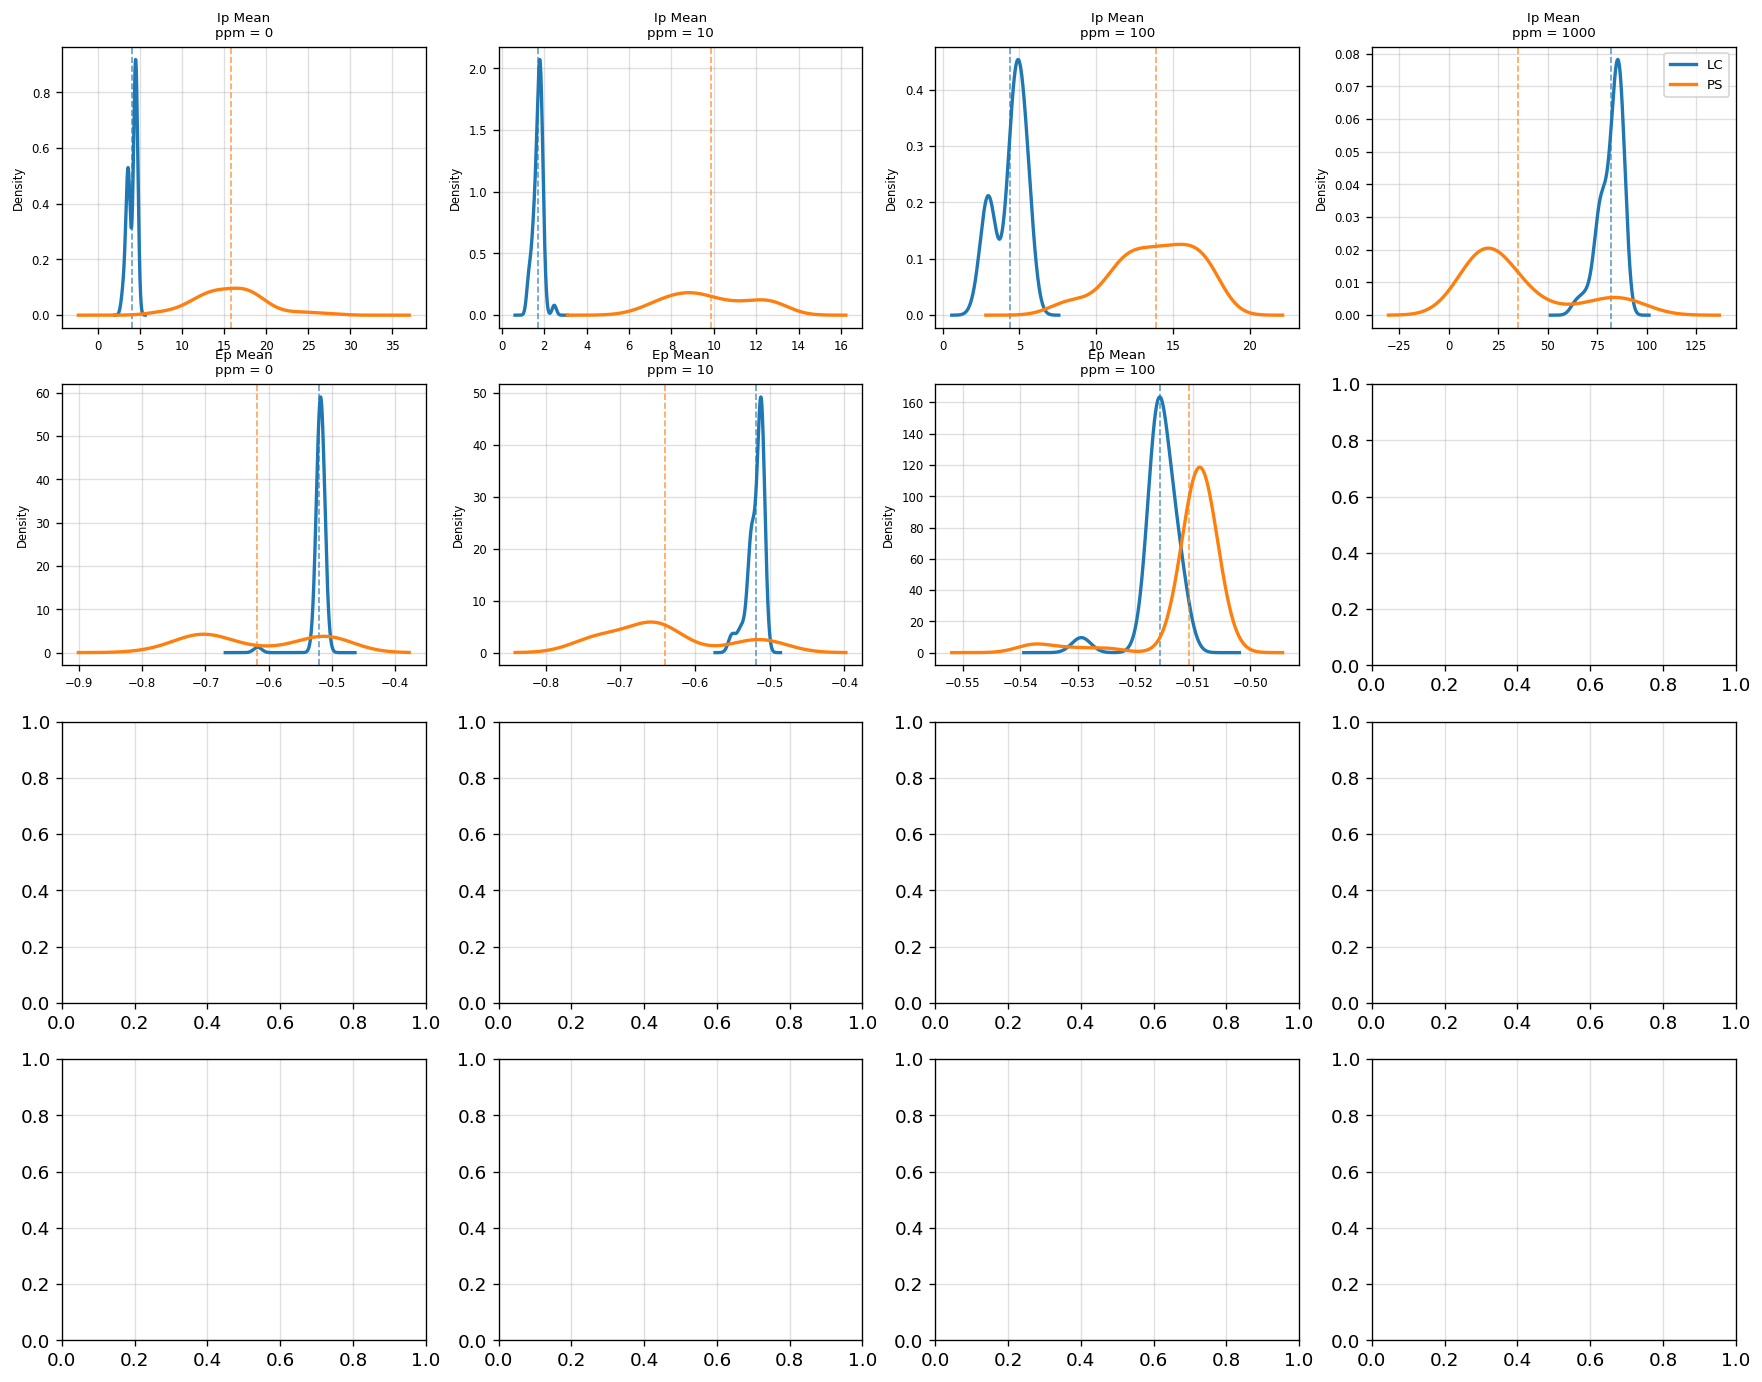

In [23]:
# Cell 16: Distribution Shift — LC vs PS pada ppm yang sama (KDE plot)
# Pilih 4 fitur kunci dan 4 level ppm representatif
KEY_FEATURES = ['upper_Ip_mean', 'upper_Ep_mean', 'upper_Area_mean', 'upper_skewness']
PPM_SHOWCASE = [0, 10, 100, 1000]

fig, axes = plt.subplots(len(KEY_FEATURES), len(PPM_SHOWCASE), figsize=(18, 14))

for row, feat in enumerate(KEY_FEATURES):
    for col, ppm_val in enumerate(PPM_SHOWCASE):
        ax = axes[row, col]

        lc_data = df_lc_imp.loc[df_lc_imp['ppm'] == ppm_val, feat].dropna()
        ps_data = df_ps_imp.loc[df_ps_imp['ppm'] == ppm_val, feat].dropna()

        # KDE plot
        if len(lc_data) >= 3:
            lc_data.plot.kde(ax=ax, color='#1f77b4', linewidth=2, label='LC')
            ax.axvline(lc_data.mean(), color='#1f77b4', linestyle='--', linewidth=1, alpha=0.7)
        if len(ps_data) >= 3:
            ps_data.plot.kde(ax=ax, color='#ff7f0e', linewidth=2, label='PS')
            ax.axvline(ps_data.mean(), color='#ff7f0e', linestyle='--', linewidth=1, alpha=0.7)

        ax.set_title(f'{feat.replace("upper_","").replace("_"," ").title()}\nppm = {ppm_val}',
                     fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('Density', fontsize=7)
        ax.tick_params(labelsize=7)

        if row == 0 and col == len(PPM_SHOWCASE) - 1:
            ax.legend(fontsize=8)

# Row labels
for row, feat in enumerate(KEY_FEATURES):
    axes[row, 0].set_ylabel(feat.replace('upper_', '').replace('_', '\n').title() + '\nDensity',
                             fontsize=8)

fig.suptitle('Distribution Shift: LC vs PS per PPM Level\n(KDE, garis putus-putus = mean)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phase2_distribution_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_phase2_distribution_shift.png')


---
## Ringkasan Temuan EDA

*(Isi setelah melihat plot di atas)*

### Korelasi Fitur vs ppm:
- **Fitur paling korelasi (LC):** *(lihat Cell 10 & 15)*
- **Fitur paling korelasi (PS):** *(lihat Cell 10 & 15)*

### Calibration Curve:
- **LC slope linear:** *(lihat Cell 14)* — positif/negatif?
- **PS slope linear:** *(lihat Cell 14)* — positif/negatif?
- Log-scale fit lebih baik karena distribusi ppm logaritmik

### Lower Peak:
- Lower peak valid pada ppm ≥ **...** (lihat Cell 13 — boxplot mulai non-trivial)
- `lower_FWHM_mean` = 0 untuk semua sampel → akan diabaikan model secara otomatis (zero variance)

### Distribution Shift LC vs PS:
- Distribusi fitur LC dan PS **berbeda signifikan** / **mirip** pada ppm rendah/tinggi
- Ini menjelaskan kenapa satu model tidak bisa merepresentasikan keduanya sekaligus

### Outlier / Anomali:
- Tidak ada anomali ekstrem yang memerlukan penanganan khusus *(atau sebutkan jika ada)*

---
**✅ Checklist Phase 2:**
- [x] Heatmap korelasi (LC + PS)
- [x] Boxplot upper peak (LC + PS)
- [x] Boxplot lower peak (LC + PS)
- [x] Calibration curve upper_Ip_mean
- [x] Mutual Information score
- [x] Distribution shift LC vs PS

**➡️ Siap lanjut ke Phase 3: Model Training**